In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ═══════════════════════════════════════════════════════════════
# PASO 1: CONFIGURACIÓN Y CARGA DE DATOS
# ═══════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, re, os
from datetime import datetime

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("╔════════════════════════════════════════════════════════════╗")
print("║   DATA PREPARATION - NNA Trabajo Infantil/Adolescente     ║")
print("╚════════════════════════════════════════════════════════════╝")
print(f"\n📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# Cargar datos (Excel, hoja 'BD')
print("📂 Cargando datos...")
ruta = '/content/drive/MyDrive/Herramientas/Python_Data_Mining/Proyecto_corte2/base_datos_completa_NNA_TI_anon.xlsx'
df_raw = pd.read_excel(ruta, sheet_name='BD', engine='openpyxl')
print(f"✅ Cargados: {df_raw.shape[0]:,} registros × {df_raw.shape[1]} columnas\n")

╔════════════════════════════════════════════════════════════╗
║   DATA PREPARATION - NNA Trabajo Infantil/Adolescente     ║
╚════════════════════════════════════════════════════════════╝

📅 2025-10-17 16:29:09

📂 Cargando datos...
✅ Cargados: 56,473 registros × 115 columnas



In [3]:
# ═══════════════════════════════════════════════════════════════
# PASO 2: ESTANDARIZACIÓN DE NOMBRES DE COLUMNAS
# (espacios → guion_bajo y TODO en MAYÚSCULAS)
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("🔧 PASO 2: estandarizando nombres de columnas")
print("="*70 + "\n")

def normalize_columns(df):
    """Quita espacios extras, reemplaza espacios por '_' y pone TODO en MAYÚSCULAS."""
    new_cols = []
    for col in df.columns:
        col_clean = str(col).strip()
        col_clean = re.sub(r'\s+', ' ', col_clean)   # colapsa espacios internos
        col_clean = col_clean.replace(' ', '_')      # en los espacios agrega un _
        col_clean = col_clean.upper()                # que todo quede en MAYÚSCULAS
        new_cols.append(col_clean)
    return new_cols

df = df_raw.copy()
df.columns = normalize_columns(df)
print(f"✓ Columnas estandarizadas: {len(df.columns)}")

🔧 PASO 2: estandarizando nombres de columnas

✓ Columnas estandarizadas: 115


In [4]:
# ═══════════════════════════════════════════════════════════════
# PASO 3: ELIMINACIÓN DE DATOS PERSONALES (PII) — base NNA-TI
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("🔒 PASO 3: Eliminando información personal identificable (PII)")
print("="*70 + "\n")

PII_COLUMNS = [
    "ID_FIC",
    "FICHA_FIC",
    "NÚMERO_DE_FICHA_ANTERIOR",
    "USUARIO",
    "DIRECCIÓN_DE_LA_VIVIENDA",
    "DIRECCIÓN_DEL_TRABAJO",
    "TELÉFONO_1",
    "TELÉFONO_2",
    "CORREO_1",
    "CORREO_2",
]

cols_to_drop = [c for c in PII_COLUMNS if c in df.columns]
print(f"🔍 Columnas PII encontradas: {len(cols_to_drop)}")
for col in cols_to_drop:
    print(f"   ❌ {col}")

df_clean = df.drop(columns=cols_to_drop)
print(f"\n✓ Dataset seguro: {df_clean.shape[0]:,} × {df_clean.shape[1]} columnas")


🔒 PASO 3: Eliminando información personal identificable (PII)

🔍 Columnas PII encontradas: 10
   ❌ ID_FIC
   ❌ FICHA_FIC
   ❌ NÚMERO_DE_FICHA_ANTERIOR
   ❌ USUARIO
   ❌ DIRECCIÓN_DE_LA_VIVIENDA
   ❌ DIRECCIÓN_DEL_TRABAJO
   ❌ TELÉFONO_1
   ❌ TELÉFONO_2
   ❌ CORREO_1
   ❌ CORREO_2

✓ Dataset seguro: 56,473 × 105 columnas


In [5]:
# ═══════════════════════════════════════════════════════════════
# PASO 4: LIMPIEZA DE INCONSISTENCIAS (solo texto y categorías)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("🧹 PASO 4: Limpiando inconsistencias en texto y categorías")
print("="*70 + "\n")

import numpy as np
import re

# A) Limpieza general de columnas tipo texto (espacios, strings vacíos → NaN)
cat_cols = df_clean.select_dtypes(include=["object"]).columns
for col in cat_cols:
    df_clean[col] = (
        df_clean[col]
        .astype(str)
        .str.replace(r"\s+", " ", regex=True)  # colapsa espacios repetidos
        .str.strip()
        .replace({"": np.nan})
    )

# B) Normalizaciones específicas (sin tocar faltantes)
if "SEXO" in df_clean.columns:
    def map_sexo(v):
        if pd.isna(v): return np.nan
        x = str(v).upper()
        if x in {"M","MASCULINO","HOMBRE"}: return "MASCULINO"
        if x in {"F","FEMENINO","MUJER"}:   return "FEMENINO"
        if "INTER" in x or "NO BIN" in x or "OTR" in x: return "INTERSEX/OTRO"
        return x
    df_clean["SEXO"] = df_clean["SEXO"].apply(map_sexo)

if "ZONA" in df_clean.columns:
    def map_zona(v):
        if pd.isna(v): return np.nan
        x = str(v).upper()
        if "URB" in x: return "URBANA"
        if "RUR" in x: return "RURAL"
        if "CENTRO" in x or "POBLAD" in x: return "CENTRO POBLADO"
        return x
    df_clean["ZONA"] = df_clean["ZONA"].apply(map_zona)

# ESTRATO auxiliar numérico (si existe alguno de los dos)
estrato_col = ("ESTRATO_SOCIOECONÓMICO" if "ESTRATO_SOCIOECONÓMICO" in df_clean.columns
               else "ESTRATO" if "ESTRATO" in df_clean.columns else None)
if estrato_col:
    def to_estrato_num(v):
        if pd.isna(v): return np.nan
        d = re.sub(r"[^\d]", "", str(v))
        return int(d) if d in {"1","2","3","4","5","6"} else np.nan
    df_clean["ESTRATO_NUM"] = df_clean[estrato_col].apply(to_estrato_num)

print("✓ Limpieza de texto/categorías completada\n")


🧹 PASO 4: Limpiando inconsistencias en texto y categorías

✓ Limpieza de texto/categorías completada



🔍 PASO 5: Analizando y manejando valores faltantes

📊 Variables con valores faltantes: 29

Top 10 con mayor % de faltantes:

                                                             Variable  Faltantes  Porcentaje
SUB-SECCIÓN_=>_INFORMACIÓN_DEL_MENOR_NNA_IDENTIFICADO_COMO_TRABAJADOR      56473       100.0
                             SUB-SECCIÓN_=>_INFORMACIÓN_DEL_ACUDIENTE      56473       100.0
                                                  ÚLTIMA_INTERVENCIÓN      56473       100.0
              SUB-SECCIÓN_=>_INTERVENCIÓN_DE_NIÑO,_NIÑA_O_ADOLESCENTE      56473       100.0
                           SUB-SECCIÓN_=>_RESULTADOS_DE_LA_REPOSICION      56473       100.0
                         SUB-SECCIÓN_=>_RESULTADOS_DE_LA_INTERVENCIÓN      56473       100.0
                                                     ACOMPAÑAMIENTO_4      56473       100.0
                                                     ACOMPAÑAMIENTO_3      56473       100.0
                                      

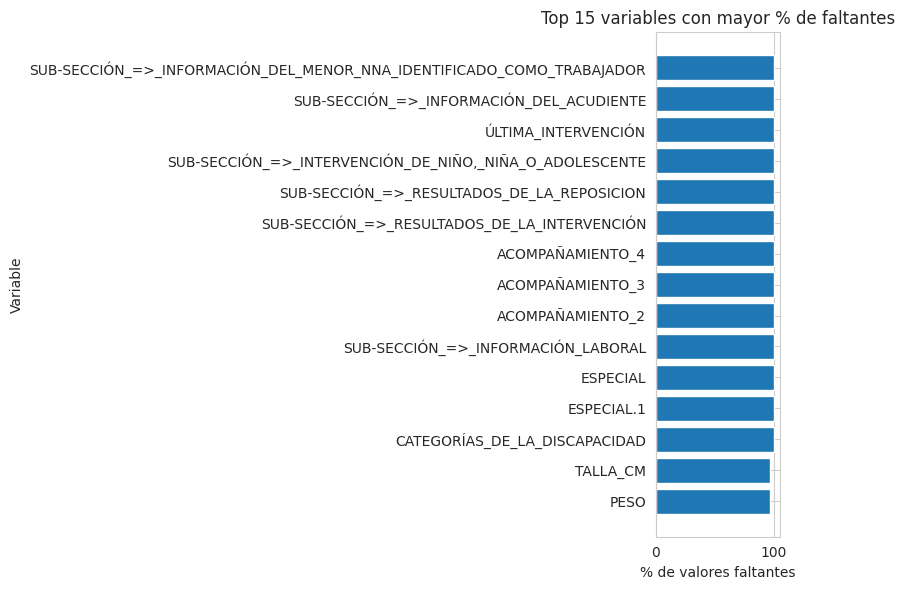

✅ Resumen guardado en: reports/resumen_faltantes.csv



In [6]:
# ═══════════════════════════════════════════════════════════════
# PASO 5: MANEJO DE VALORES FALTANTES (
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("🔍 PASO 5: Analizando y manejando valores faltantes")
print("="*70 + "\n")

import numpy as np
import matplotlib.pyplot as plt
import os

# 1) Reemplazar tokens de faltantes por NaN
missing_tokens_text = {
    "", " ", "NA", "N/A", "na", "n/a", "NaN", "null", "NULL", "None",
    "SIN DATO", "SIN_DATO", "SIN INFORMACION", "SIN INFORMACIÓN",
    "NO REPORTA", "NO SABE", "NS/NR", "NO REGISTRA", "NO INFORMA",
    ".", "-", "--",
    # Variantes de NO APLICA
    "NO APLICA", "No aplica", "no aplica", "NO_APLICA", "N/A.", ".NO APLICA",
    "NO SE APLICA", "NO CORRESPONDE"
}
missing_tokens_nums = {99999, 99.999, 9999, 999, -9999}

# Reemplazo en columnas object (texto)
obj_cols = df_clean.select_dtypes(include=["object"]).columns
for col in obj_cols:
    df_clean[col] = df_clean[col].replace(missing_tokens_text, np.nan)

# Reemplazo numérico global
df_clean = df_clean.replace(list(missing_tokens_nums), np.nan)

# 2) Resumen de faltantes
missing_summary = (
    pd.DataFrame({
        "Variable": df_clean.columns,
        "Faltantes": df_clean.isna().sum(),
        "Porcentaje": (df_clean.isna().sum() / len(df_clean) * 100).round(2)
    })
    .sort_values("Porcentaje", ascending=False)
    .reset_index(drop=True)
)

print("📊 Variables con valores faltantes:", (missing_summary["Faltantes"] > 0).sum())
print("\nTop 10 con mayor % de faltantes:\n")
print(missing_summary.head(10).to_string(index=False))

# 3) Heurística: variables condicionales (saltos lógicos) → >30% NA
conditional_questions = (
    missing_summary.loc[missing_summary["Porcentaje"] > 30, "Variable"].tolist()
)
if conditional_questions:
    print(f"\n⚠️  Variables condicionales identificadas ({len(conditional_questions)}):")
    print("   (Valores faltantes pueden ser ESPERADOS por salto de pregunta)")
    for var in conditional_questions[:15]:
        pct = float(missing_summary.loc[missing_summary["Variable"] == var, "Porcentaje"].values[0])
        print(f"   • {var[:70]}... ({pct}%)")

# 4) Imputación SOLO en categóricas NO condicionales
print("\n🔧 Imputando valores faltantes en categóricas no condicionales...")
categorical_cols = df_clean.select_dtypes(include=["object"]).columns

# Opcional: excluir explícitamente variables que no queremos imputar aunque sean object
excluir_de_imputacion = {"EDAD"}  # mantenemos EDAD sin tocar (si estuviera como texto)
imputaciones = 0
for col in categorical_cols:
    if (col not in conditional_questions) and (col not in excluir_de_imputacion):
        n_missing = int(df_clean[col].isna().sum())
        if n_missing > 0:
            df_clean[col] = df_clean[col].fillna("No especificado")
            imputaciones += 1

print(f"✓ {imputaciones} variables categóricas imputadas con 'No especificado'\n")

# 5) Visualización rápida (opcional)
try:
    plt.figure(figsize=(8, 6))
    top_vars = missing_summary.head(15)
    plt.barh(top_vars["Variable"], top_vars["Porcentaje"])
    plt.xlabel("% de valores faltantes")
    plt.ylabel("Variable")
    plt.title("Top 15 variables con mayor % de faltantes")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f"(Aviso) No se pudo generar la gráfica de faltantes: {e}")

# 6) Guardar resumen a /reports
os.makedirs("reports", exist_ok=True)
missing_summary.to_csv("reports/resumen_faltantes.csv", index=False, encoding="utf-8-sig")
print("✅ Resumen guardado en: reports/resumen_faltantes.csv\n")

In [7]:
# ═══════════════════════════════════════════════════════════════
# PASO 6: VARIABLES DERIVADAS (manteniendo etiquetas originales)
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("🔨 PASO 6: Creando variables derivadas (etiquetas originales)")
print("="*70 + "\n")

nuevas_vars = []

import re

def _code_from_cell(cell):
    """Extrae un código numérico inicial (1,2,3,...) si existe, sino NaN."""
    if pd.isna(cell):
        return np.nan
    s = str(cell).strip()
    # Si viene ya como '1- Urbana' ó '2. Bajo' etc., extrae el primer entero
    m = re.match(r'^\s*(\d+)', s)
    if m:
        try:
            return int(m.group(1))
        except:
            return np.nan
    # Si es 99999 u otras formas
    if s in ["99999", "99.999", "99,999"]:
        return np.nan
    return np.nan

def _map_with_canonical(df_col, canonical_map):
    """
    Convierte una columna a las etiquetas canónicas:
    - Si empieza con un código que está en el diccionario, devuelve esa etiqueta exacta
    - Si es '99999' o NaN -> 'No especificado'
    - Si ya coincide con alguna etiqueta canónica (por texto), la respeta
    """
    def _map_cell(x):
        if pd.isna(x):
            return "No especificado"
        s = str(x).strip()
        if s in ["99999", "99.999", "99,999", "", " "]:
            return "No especificado"
        # Si ya coincide con alguna etiqueta en el map (valor), respétala
        if s in canonical_map.values():
            return s
        # Intentar por código inicial
        code = _code_from_cell(s)
        if not pd.isna(code) and int(code) in canonical_map:
            return canonical_map[int(code)]
        # Si no matchea, deja como 'No especificado' para evitar ruido
        return "No especificado"
    return df_col.apply(_map_cell)

# 6.1 RANGO_EDAD (derivada a partir de EDAD)
if 'EDAD' in df_clean.columns:
    print("1️⃣  Creando 'RANGO_EDAD'…")
    edad_num = pd.to_numeric(df_clean['EDAD'], errors='coerce')
    bins   = [-1, 5, 11, 14, 17, 120]
    labels = ['0-5', '6-11', '12-14', '15-17', '18+']
    df_clean['RANGO_EDAD'] = pd.cut(edad_num, bins=bins, labels=labels)
    nuevas_vars.append('RANGO_EDAD')
    print("   ✓ Creada")
    print("   Distribución:")
    print(df_clean['RANGO_EDAD'].value_counts(dropna=False))
    print()

# 6.2 ZONA_LABEL (usando tus etiquetas exactas)
if 'ZONA' in df_clean.columns:
    print("2️⃣  Creando 'ZONA_LABEL'…")
    zona_map = {
        1: "1- Urbana",
        2: "2- Rural",
        3: "3-Periurbana",
    }
    df_clean['ZONA_LABEL'] = _map_with_canonical(df_clean['ZONA'], zona_map)
    nuevas_vars.append('ZONA_LABEL')
    print("   ✓ Creada")
    print("   Distribución:")
    print(df_clean['ZONA_LABEL'].value_counts(dropna=False))
    print()

# 6.3 SEXO_LABEL (usando tus etiquetas exactas)
if 'SEXO' in df_clean.columns:
    print("3️⃣  Creando 'SEXO_LABEL'…")
    sexo_map = {
        1: "1- Hombre",
        2: "2- Mujer",
        3: "3- Intersexual",
    }
    df_clean['SEXO_LABEL'] = _map_with_canonical(df_clean['SEXO'], sexo_map)
    nuevas_vars.append('SEXO_LABEL')
    print("   ✓ Creada")
    print("   Distribución:")
    print(df_clean['SEXO_LABEL'].value_counts(dropna=False))
    print()

# 6.4 ESTRATO_SOCIOECONÓMICO_LABEL (usando tus etiquetas exactas)
if 'ESTRATO_SOCIOECONÓMICO' in df_clean.columns:
    print("4️⃣  Creando 'ESTRATO_SOCIOECONÓMICO_LABEL'…")
    estrato_map = {
        1: "1. Bajo-bajo",
        2: "2. Bajo",
        3: "3. Medio-bajo",
    }
    df_clean['ESTRATO_SOCIOECONÓMICO_LABEL'] = _map_with_canonical(
        df_clean['ESTRATO_SOCIOECONÓMICO'], estrato_map
    )
    nuevas_vars.append('ESTRATO_SOCIOECONÓMICO_LABEL')
    print("   ✓ Creada")
    print("   Distribución:")
    print(df_clean['ESTRATO_SOCIOECONÓMICO_LABEL'].value_counts(dropna=False))
    print()

# 6.5 LUGAR_TRABAJO_LABEL (¿EN_DONDE_REALIZA_PRINCIPALMENTE_SU_TRABAJO?)
col_lugar = '¿EN_DONDE_REALIZA_PRINCIPALMENTE_SU_TRABAJO?'
if col_lugar in df_clean.columns:
    print("5️⃣  Creando 'LUGAR_TRABAJO_LABEL'…")
    lugar_map = {
        1: "1. En la vivienda que habita",
        2: "2. En la calle, estacionario o ambulante",
        3: "3. En el campo",
        4: "4. En una UTI",
        5: "5. En otra vivienda",
        6: "6. Establecimientos abiertos al público",
        7: "7. En una UTI | En otra vivienda",
    }
    df_clean['LUGAR_TRABAJO_LABEL'] = _map_with_canonical(df_clean[col_lugar], lugar_map)
    nuevas_vars.append('LUGAR_TRABAJO_LABEL')
    print("   ✓ Creada")
    print("   Distribución:")
    print(df_clean['LUGAR_TRABAJO_LABEL'].value_counts(dropna=False))
    print()

# 6.6 AFILIACIÓN_AL_SGSSS_LABEL + FLAG_AFILIACION_SGSSS
if 'AFILIACIÓN_AL_SGSSS' in df_clean.columns:
    print("6️⃣  Creando 'AFILIACIÓN_AL_SGSSS_LABEL' y 'FLAG_AFILIACION_SGSSS'…")
    afili_map = {
        1: "1- Subsidiado",
        2: "2- Contributivo",
        3: "3- Régimen de excepción/especial",
        4: "4- Vinculado",
        5: "5- No asegurado",
    }
    df_clean['AFILIACIÓN_AL_SGSSS_LABEL'] = _map_with_canonical(
        df_clean['AFILIACIÓN_AL_SGSSS'], afili_map
    )
    # Flag afiliado: 1 si está en 1–4; 0 si es "5- No asegurado"; NaN si "No especificado"
    df_clean['FLAG_AFILIACION_SGSSS'] = df_clean['AFILIACIÓN_AL_SGSSS_LABEL'].map({
        "1- Subsidiado": 1,
        "2- Contributivo": 1,
        "3- Régimen de excepción/especial": 1,
        "4- Vinculado": 1,
        "5- No asegurado": 0,
        "No especificado": np.nan
    })
    nuevas_vars.extend(['AFILIACIÓN_AL_SGSSS_LABEL', 'FLAG_AFILIACION_SGSSS'])
    print("   ✓ Creada")
    print("   Distribución (AFILIACIÓN_AL_SGSSS_LABEL):")
    print(df_clean['AFILIACIÓN_AL_SGSSS_LABEL'].value_counts(dropna=False))
    print("\n   Distribución (FLAG_AFILIACION_SGSSS):")
    print(df_clean['FLAG_AFILIACION_SGSSS'].value_counts(dropna=False))
    try:
        print(f"\n   % Afiliados (sobre válidos): {df_clean['FLAG_AFILIACION_SGSSS'].mean(skipna=True)*100:.1f}%")
    except:
        pass
    print()

# 6.7 ESTADO_RESULTADO (a partir de DESVINCULADO / TRABAJO_PROTEGIDO)
col_desv = 'NNA_DESVINCULADO_DE_LA_ACTIVIDAD_LABORAL'
col_prot = 'ADOLESCENTE_TRABAJO_PROTEGIDO'
cand_desv = [c for c in df_clean.columns if 'DESVINCULADO' in c.upper()]
cand_prot = [c for c in df_clean.columns if 'TRABAJO_PROTEGIDO' in c.upper()]
if cand_desv: col_desv = cand_desv[0]
if cand_prot: col_prot = cand_prot[0]

if (col_desv in df_clean.columns) or (col_prot in df_clean.columns):
    print("7️⃣  Creando 'ESTADO_RESULTADO'…")
    desv = df_clean[col_desv].astype(str).str.lower() if col_desv in df_clean.columns else pd.Series(['']*len(df_clean))
    prot = df_clean[col_prot].astype(str).str.lower() if col_prot in df_clean.columns else pd.Series(['']*len(df_clean))
    def map_estado(d, p):
        dsi = any(k in d for k in ['si','sí','desvinc'])
        psi = any(k in p for k in ['si','sí','proteg'])
        if dsi: return 'Desvinculado'
        if psi: return 'Trabajo protegido'
        return 'En proceso / Sin cambio'
    df_clean['ESTADO_RESULTADO'] = [map_estado(a, b) for a, b in zip(desv, prot)]
    nuevas_vars.append('ESTADO_RESULTADO')
    print("   ✓ Creada")
    print("   Distribución:")
    print(df_clean['ESTADO_RESULTADO'].value_counts(dropna=False))
    print()

# 6.8 UPZ_UPR_ALIAS (alias directo para usar y cruzar)
upz_col = 'UPZ/UPR' if 'UPZ/UPR' in df_clean.columns else ('UPZ_UPR' if 'UPZ_UPR' in df_clean.columns else None)
if upz_col:
    print("8️⃣  Creando 'UPZ_UPR_ALIAS'…")
    df_clean['UPZ_UPR_ALIAS'] = df_clean[upz_col]
    nuevas_vars.append('UPZ_UPR_ALIAS')
    print("   ✓ Creada (sin transformación)")
    print("   Top 10 valores más frecuentes:")
    print(df_clean['UPZ_UPR_ALIAS'].value_counts(dropna=False).head(10))
    print()

print(f"\n✅ Variables derivadas creadas: {len(nuevas_vars)}")
print(f"   → {nuevas_vars}\n")

🔨 PASO 6: Creando variables derivadas (etiquetas originales)

1️⃣  Creando 'RANGO_EDAD'…
   ✓ Creada
   Distribución:
RANGO_EDAD
NaN      24728
6-11     12947
0-5       8407
12-14     5946
15-17     4409
18+         36
Name: count, dtype: int64

2️⃣  Creando 'ZONA_LABEL'…
   ✓ Creada
   Distribución:
ZONA_LABEL
No especificado    56473
Name: count, dtype: int64

3️⃣  Creando 'SEXO_LABEL'…
   ✓ Creada
   Distribución:
SEXO_LABEL
1- Hombre          22956
2- Mujer           22343
No especificado    11174
Name: count, dtype: int64

4️⃣  Creando 'ESTRATO_SOCIOECONÓMICO_LABEL'…
   ✓ Creada
   Distribución:
ESTRATO_SOCIOECONÓMICO_LABEL
2. Bajo            29520
No especificado    11458
3. Medio-bajo       9046
1. Bajo-bajo        6449
Name: count, dtype: int64

5️⃣  Creando 'LUGAR_TRABAJO_LABEL'…
   ✓ Creada
   Distribución:
LUGAR_TRABAJO_LABEL
4. En una UTI                               29966
No especificado                             15439
2. En la calle, estacionario o ambulante     7207
1

In [8]:
nuevas_vars

['RANGO_EDAD',
 'ZONA_LABEL',
 'SEXO_LABEL',
 'ESTRATO_SOCIOECONÓMICO_LABEL',
 'LUGAR_TRABAJO_LABEL',
 'AFILIACIÓN_AL_SGSSS_LABEL',
 'FLAG_AFILIACION_SGSSS',
 'ESTADO_RESULTADO',
 'UPZ_UPR_ALIAS']

In [9]:
# ═══════════════════════════════════════════════════════════════
# PASO 7: ESTRUCTURACIÓN FINAL (grupos temáticos NNA-TI)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📋 PASO 7: Estructurando dataset final (variables foco)")
print("="*70 + "\n")

# Definir orden de columnas por grupos temáticos (se incluyen solo si existen)
GRUPOS_ORDENADOS = {
    "METADATA": [
        "BASE_ORIGEN", "FECHA_INTERVENCION", "LOCALIDAD_FIC", "RED_FIC"
    ],

    "UBICACION": [
        "LOCALIDAD",
        "ZONA_LABEL", "ZONA",            # label + cruda
        "BARRIO",
        "UPZ_UPR_ALIAS", "UPZ/UPR"       # alias + cruda (si existe)
    ],

    "DEMOGRAFIA": [
        "SEXO_LABEL", "SEXO",
        "ESTRATO_SOCIOECONÓMICO_LABEL", "ESTRATO_SOCIOECONÓMICO",
        "ESTADO_CIVIL",
        "EDAD", "RANGO_EDAD"
    ],

    "TRABAJO": [
        "¿EN_DONDE_REALIZA_PRINCIPALMENTE_SU_TRABAJO?",
        "LUGAR_TRABAJO_LABEL"
    ],

    "SALUD": [
        "AFILIACIÓN_AL_SGSSS_LABEL",
        "AFILIACIÓN_AL_SGSSS",
        "FLAG_AFILIACION_SGSSS"          # lo usamos para cruces; no lo graficamos si no quieres
    ],

    "RESULTADO": [
        "ESTADO_RESULTADO"
    ],
}

# Construir la lista ordenada respetando existencia y sin duplicar
columnas_ordenadas = []
for grupo, cols in GRUPOS_ORDENADOS.items():
    existentes = [c for c in cols if c in df_clean.columns]
    columnas_ordenadas.extend([c for c in existentes if c not in columnas_ordenadas])

# Agregar al final cualquier otra columna que no haya quedado en los grupos
resto = [c for c in df_clean.columns if c not in columnas_ordenadas]
columnas_ordenadas.extend(resto)

# Reordenar
df_final = df_clean[columnas_ordenadas].copy()

print(f"✓ Columnas reordenadas por grupos temáticos")


📋 PASO 7: Estructurando dataset final (variables foco)

✓ Columnas reordenadas por grupos temáticos


In [10]:
# ═══════════════════════════════════════════════════════════════
# PASO 9: EXPORTAR RESULTADOS (NNA-TI)
# ═══════════════════════════════════════════════════════════════

print("="*70)
print("💾 PASO 9: Exportando resultados")
print("="*70 + "\n")

# 0) Carpetas
os.makedirs('data/procesados', exist_ok=True)
os.makedirs('reports', exist_ok=True)

# ----------------------------------------------------------------
# 1) CSV limpio
# ----------------------------------------------------------------
output_csv = 'data/procesados/NNA_TI_preparada.csv'
df_final.to_csv(output_csv, index=False, encoding='utf-8-sig')
size_csv = os.path.getsize(output_csv) / 1024**2
print(f"✓ CSV: {output_csv} ({size_csv:.2f} MB)")

# ----------------------------------------------------------------
# 2) Excel limpio
# ----------------------------------------------------------------
output_excel = 'data/procesados/NNA_TI_preparada.xlsx'
df_final.to_excel(output_excel, index=False, engine='openpyxl')
size_excel = os.path.getsize(output_excel) / 1024**2
print(f"✓ Excel: {output_excel} ({size_excel:.2f} MB)")

# ----------------------------------------------------------------
# 3) Diccionario de datos (perfil de columnas)
# ----------------------------------------------------------------
data_dict = pd.DataFrame({
    'Columna': df_final.columns,
    'Tipo': df_final.dtypes.astype(str).values,
    'No_Nulos': df_final.notnull().sum().values,
    'Nulos': df_final.isnull().sum().values,
    'Pct_Nulos': (df_final.isnull().sum() / len(df_final) * 100).round(2).values,
    'Valores_Unicos': [df_final[c].nunique(dropna=True) for c in df_final.columns],
})
dicc_out = 'reports/diccionario_datos_final.csv'
data_dict.to_csv(dicc_out, index=False, encoding='utf-8-sig')
print(f"✓ Diccionario: {dicc_out}")

# ----------------------------------------------------------------
# 4) Reporte de transformaciones (JSON)
# ----------------------------------------------------------------
import json

total_nulls = int(df_final.isnull().sum().sum())
pct_nulls = round(total_nulls / (df_final.shape[0] * df_final.shape[1]) * 100, 2)
dup_rows = int(df_final.duplicated().sum())

# Variables auxiliares que podrían no existir si se omitieron pasos
pii_eliminadas = len(cols_to_drop) if 'cols_to_drop' in locals() else 0
# imputaciones categóricas: si en tu PASO 5 guardaste una variable, úsala aquí;
# si no existe, lo dejamos en 0 para evitar errores.
imputaciones_categoricas = (
    imputaciones_cat if 'imputaciones_cat' in locals()
    else (imputaciones if 'imputaciones' in locals() else 0)
)

# variables derivadas creadas en PASO 6
vars_creadas = nuevas_vars if 'nuevas_vars' in locals() else []

reporte = {
    'fecha_proceso': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_original': {
        'filas': int(df_raw.shape[0]) if 'df_raw' in locals() else None,
        'columnas': int(df_raw.shape[1]) if 'df_raw' in locals() else None,
    },
    'dataset_final': {
        'filas': int(df_final.shape[0]),
        'columnas': int(df_final.shape[1]),
    },
    'transformaciones_realizadas': {
        'pii_eliminadas': pii_eliminadas,
        'espacios_limpiados': True,                       # PASO 4
        'tokens_faltantes_normalizados': True,            # PASO 5
        'categoricas_imputadas': int(imputaciones_categoricas),
        'variables_derivadas': len(vars_creadas),         # PASO 6
        'columnas_reordenadas': True,                     # PASO 7
        'labels_canonicas_aplicadas': True                # mapeos *_LABEL
    },
    'variables_creadas': vars_creadas,
    'calidad_final': {
        'valores_faltantes_totales': total_nulls,
        'pct_faltantes_total': pct_nulls,
        'filas_duplicadas': dup_rows,
    },
    'archivos_salida': {
        'csv': output_csv,
        'excel': output_excel,
        'diccionario': dicc_out
    }
}

rep_out = 'reports/reporte_transformaciones.json'
with open(rep_out, 'w', encoding='utf-8') as f:
    json.dump(reporte, f, indent=2, ensure_ascii=False)

print(f"✓ Reporte: {rep_out}")
print("\n✅ Exportación completada exitosamente\n")

💾 PASO 9: Exportando resultados

✓ CSV: data/procesados/NNA_TI_preparada.csv (45.61 MB)
✓ Excel: data/procesados/NNA_TI_preparada.xlsx (23.96 MB)
✓ Diccionario: reports/diccionario_datos_final.csv
✓ Reporte: reports/reporte_transformaciones.json

✅ Exportación completada exitosamente



In [11]:
# ═══════════════════════════════════════════════════════════════
# PASO 10: VISUALIZACIONES FINALES (NNA-TI)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Generando visualizaciones finales")
print("="*70 + "\n")

os.makedirs('reports', exist_ok=True)

# --------------------------------------------------------------
# 1) Comparación antes / después (columnas)
# --------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1.1 Número de columnas
cats = ['Original', 'Final']
cols = [df_raw.shape[1] if 'df_raw' in locals() else None, df_final.shape[1]]
ax[0].bar(cats, cols, color=['#e74c3c', '#27ae60'])
ax[0].set_title('Número de Columnas', fontweight='bold')
ax[0].set_ylabel('Columnas')
for i, v in enumerate(cols):
    if v is not None:
        ax[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 1.2 Número de filas
rows = [df_raw.shape[0] if 'df_raw' in locals() else None, df_final.shape[0]]
ax[1].bar(cats, rows, color=['#8e44ad', '#2980b9'])
ax[1].set_title('Número de Filas', fontweight='bold')
ax[1].set_ylabel('Filas')
for i, v in enumerate(rows):
    if v is not None:
        ax[1].text(i, v + max(1, v*0.01), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/comparacion_final.png', dpi=300, bbox_inches='tight')
print("✓ Visualización: reports/comparacion_final.png")
plt.close()

# --------------------------------------------------------------
# 2) Dashboard de distribuciones clave (etiquetas originales)
#    Intentará graficar hasta 6 variables si existen
# --------------------------------------------------------------
vars_para_mostrar = [
    ('RANGO_EDAD', 'Distribución: Rango de Edad'),
    ('SEXO_LABEL', 'Distribución: Sexo'),
    ('ZONA_LABEL', 'Distribución: Zona'),
    ('ESTRATO_SOCIOECONÓMICO_LABEL', 'Distribución: Estrato Socioeconómico'),
    ('AFILIACIÓN_AL_SGSSS_LABEL', 'Distribución: Afiliación al SGSSS'),
    ('ESTADO_RESULTADO', 'Distribución: Estado de Resultado'),
]

presentes = [(c, t) for c, t in vars_para_mostrar if c in df_final.columns]
n = len(presentes)

if n > 0:
    # hasta 6 subplots (2x3). Si hay menos, solo llena los que existan
    filas, cols_grid = 2, 3
    fig, axes = plt.subplots(filas, cols_grid, figsize=(16, 9))
    axes = axes.flatten()

    for i, (col, titulo) in enumerate(presentes[:filas*cols_grid]):
        dist = df_final[col].value_counts(dropna=False)
        axes[i].barh(range(len(dist)), dist.values)
        axes[i].set_yticks(range(len(dist)))
        # etiquetas truncadas suaves para que no se monten
        axes[i].set_yticklabels([str(x) if len(str(x)) <= 32 else str(x)[:29]+'…' for x in dist.index], fontsize=9)
        axes[i].invert_yaxis()
        axes[i].set_title(titulo, fontweight='bold')
        axes[i].set_xlabel('Frecuencia')
        # anotar valores
        for j, v in enumerate(dist.values):
            axes[i].text(v + max(1, v*0.01), j, str(v), va='center', fontsize=8)

    # limpiar ejes sobrantes si hay menos de 6
    for k in range(len(presentes), filas*cols_grid):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.savefig('reports/distribuciones_basicas.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización: reports/distribuciones_basicas.png")
    plt.close()
else:
    print("⚠️ No se encontraron variables clave para el dashboard de distribuciones.")

# --------------------------------------------------------------
# 3) Cruce ilustrativo: ESTADO_RESULTADO × ZONA_LABEL (si existen)
# --------------------------------------------------------------
if ('ESTADO_RESULTADO' in df_final.columns) and ('ZONA_LABEL' in df_final.columns):
    ct = pd.crosstab(df_final['ZONA_LABEL'], df_final['ESTADO_RESULTADO'], normalize='index') * 100
    fig, ax = plt.subplots(figsize=(10, 6))
    ct.round(1).plot(kind='bar', stacked=True, ax=ax)
    ax.set_title('Estado de Resultado (%) por Zona', fontweight='bold')
    ax.set_xlabel('Zona')
    ax.set_ylabel('Porcentaje')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('reports/estado_resultado_por_zona.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización: reports/estado_resultado_por_zona.png")
    plt.close()
else:
    print("ℹ️ Cruce ESTADO_RESULTADO × ZONA_LABEL no generado (faltan columnas).")

# --------------------------------------------------------------
# 4) Resumen Final
# --------------------------------------------------------------
print("\n" + "="*70)
print("✨ DATA PREPARATION COMPLETADA ✨")
print("="*70 + "\n")

orig_shape = f"{df_raw.shape[0]:,} × {df_raw.shape[1]}" if 'df_raw' in locals() else "N/A"
final_shape = f"{df_final.shape[0]:,} × {df_final.shape[1]}"
pii_drop = len(cols_to_drop) if 'cols_to_drop' in locals() else 0
creadas = len(nuevas_vars) if 'nuevas_vars' in locals() else 0

print("📊 RESUMEN DE TRANSFORMACIONES:\n")
print(f"   Original: {orig_shape} columnas")
print(f"   Final: {final_shape} columnas")
print(f"   Eliminadas (PII): {pii_drop} columnas")
print(f"   Creadas (derivadas): {creadas} variables\n")

print("📁 ARCHIVOS GENERADOS:")
print("   ✓ data/procesados/NNA_TI_preparada.csv")
print("   ✓ data/procesados/NNA_TI_preparada.xlsx")
print("   ✓ reports/diccionario_datos_final.csv")
print("   ✓ reports/reporte_transformaciones.json")
print("   ✓ reports/comparacion_final.png")
if n > 0:
    print("   ✓ reports/distribuciones_basicas.png")
if ('ESTADO_RESULTADO' in df_final.columns) and ('ZONA_LABEL' in df_final.columns):
    print("   ✓ reports/estado_resultado_por_zona.png")

if 'nuevas_vars' in locals() and nuevas_vars:
    print("\n🔑 VARIABLES CLAVE CREADAS:")
    for var in nuevas_vars:
        print(f"   • {var}")

print("\n🎯 DATASET LISTO PARA:")
print("   • Describir NNA con indicios de TI/TA por territorio")
print("   • Cruces por sexo, zona, estrato y afiliación")
print("   • Resultados de intervención (desvinculación / trabajo protegido)")
print("   • Exploración adicional por UPZ/UPR y barrio")
print("\n" + "="*70)
print(f"📅 Finalizado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70 + "\n")


📊 Generando visualizaciones finales

✓ Visualización: reports/comparacion_final.png
✓ Visualización: reports/distribuciones_basicas.png
✓ Visualización: reports/estado_resultado_por_zona.png

✨ DATA PREPARATION COMPLETADA ✨

📊 RESUMEN DE TRANSFORMACIONES:

   Original: 56,473 × 115 columnas
   Final: 56,473 × 115 columnas
   Eliminadas (PII): 10 columnas
   Creadas (derivadas): 9 variables

📁 ARCHIVOS GENERADOS:
   ✓ data/procesados/NNA_TI_preparada.csv
   ✓ data/procesados/NNA_TI_preparada.xlsx
   ✓ reports/diccionario_datos_final.csv
   ✓ reports/reporte_transformaciones.json
   ✓ reports/comparacion_final.png
   ✓ reports/distribuciones_basicas.png
   ✓ reports/estado_resultado_por_zona.png

🔑 VARIABLES CLAVE CREADAS:
   • RANGO_EDAD
   • ZONA_LABEL
   • SEXO_LABEL
   • ESTRATO_SOCIOECONÓMICO_LABEL
   • LUGAR_TRABAJO_LABEL
   • AFILIACIÓN_AL_SGSSS_LABEL
   • FLAG_AFILIACION_SGSSS
   • ESTADO_RESULTADO
   • UPZ_UPR_ALIAS

🎯 DATASET LISTO PARA:
   • Describir NNA con indicios de TI/T

In [12]:
# ═══════════════════════════════════════════════════════════════
# PASO 10: VISUALIZACIONES FINALES (NNA-TI)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Generando visualizaciones finales")
print("="*70 + "\n")

os.makedirs('reports', exist_ok=True)

# --------------------------------------------------------------
# 1) Comparación antes / después (columnas/filas)
# --------------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1.1 Número de columnas
cats = ['Original', 'Final']
cols = [df_raw.shape[1] if 'df_raw' in locals() else None, df_final.shape[1]]
ax[0].bar(cats, cols, color=['#e74c3c', '#27ae60'])
ax[0].set_title('Número de Columnas', fontweight='bold')
ax[0].set_ylabel('Columnas')
for i, v in enumerate(cols):
    if v is not None:
        ax[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold')

# 1.2 Número de filas
rows = [df_raw.shape[0] if 'df_raw' in locals() else None, df_final.shape[0]]
ax[1].bar(cats, rows, color=['#8e44ad', '#2980b9'])
ax[1].set_title('Número de Filas', fontweight='bold')
ax[1].set_ylabel('Filas')
for i, v in enumerate(rows):
    if v is not None:
        ax[1].text(i, v + max(1, v*0.01), str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('reports/comparacion_final.png', dpi=300, bbox_inches='tight')
print("✓ Visualización: reports/comparacion_final.png")
plt.close()

# --------------------------------------------------------------
# 2) Dashboard de distribuciones clave (etiquetas originales)
#    Intentará graficar hasta 6 variables si existen
# --------------------------------------------------------------
vars_para_mostrar = [
    ('RANGO_EDAD', 'Distribución: Rango de Edad'),
    ('SEXO_LABEL', 'Distribución: Sexo'),
    ('ZONA_LABEL', 'Distribución: Zona'),
    ('ESTRATO_SOCIOECONÓMICO_LABEL', 'Distribución: Estrato Socioeconómico'),
    ('AFILIACIÓN_AL_SGSSS_LABEL', 'Distribución: Afiliación al SGSSS'),
    ('ESTADO_RESULTADO', 'Distribución: Estado de Resultado'),
]

presentes = [(c, t) for c, t in vars_para_mostrar if c in df_final.columns]
n = len(presentes)

def _palette_for(i, n_barras):
    """Devuelve una lista de colores distinta por subplot."""
    cmaps = ['tab20', 'Set2', 'Paired', 'Accent', 'Dark2', 'Set3']
    cmap = plt.cm.get_cmap(cmaps[i % len(cmaps)], n_barras)
    return [cmap(j) for j in range(n_barras)]

if n > 0:
    # hasta 6 subplots (2x3). Si hay menos, solo llena los que existan
    filas, cols_grid = 2, 3
    fig, axes = plt.subplots(filas, cols_grid, figsize=(16, 9))
    axes = axes.flatten()

    for i, (col, titulo) in enumerate(presentes[:filas*cols_grid]):
        dist = df_final[col].value_counts(dropna=False)
        colors = _palette_for(i, len(dist))
        axes[i].barh(range(len(dist)), dist.values, color=colors)
        axes[i].set_yticks(range(len(dist)))
        # etiquetas truncadas suaves para que no se monten
        axes[i].set_yticklabels([str(x) if len(str(x)) <= 32 else str(x)[:29]+'…'
                                 for x in dist.index], fontsize=9)
        axes[i].invert_yaxis()
        axes[i].set_title(titulo, fontweight='bold')
        axes[i].set_xlabel('Frecuencia')
        # anotar valores
        for j, v in enumerate(dist.values):
            axes[i].text(v + max(1, v*0.01), j, str(v), va='center', fontsize=8)

    # limpiar ejes sobrantes si hay menos de 6
    for k in range(len(presentes), filas*cols_grid):
        fig.delaxes(axes[k])

    plt.tight_layout()
    plt.savefig('reports/distribuciones_basicas.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización: reports/distribuciones_basicas.png")
    plt.close()
else:
    print("⚠️ No se encontraron variables clave para el dashboard de distribuciones.")

# --------------------------------------------------------------
# 2B) Gráficas específicas extra (Estrato y Lugar de trabajo)
#     Colores diferentes y manejo seguro de categóricas
# --------------------------------------------------------------
# Estrato
if 'ESTRATO_SOCIOECONÓMICO_LABEL' in df_final.columns:
    s = df_final['ESTRATO_SOCIOECONÓMICO_LABEL'].astype('object').fillna("No especificado")
    dist = s.value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(8, 5))
    colors = plt.cm.Set2(range(len(dist)))
    ax.barh(range(len(dist)), dist.values, color=colors)
    ax.set_yticks(range(len(dist)))
    ax.set_yticklabels(dist.index, fontsize=9)
    ax.invert_yaxis()
    ax.set_title('Distribución: Estrato Socioeconómico', fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for j, v in enumerate(dist.values):
        ax.text(v + max(1, v*0.01), j, str(v), va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('reports/distribucion_estrato.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización: reports/distribucion_estrato.png")
    plt.close()

# Lugar de trabajo
if 'LUGAR_TRABAJO_LABEL' in df_final.columns:
    s = df_final['LUGAR_TRABAJO_LABEL'].astype('object').fillna("No especificado")
    dist = s.value_counts(dropna=False)
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = plt.cm.Paired(range(len(dist)))
    ax.barh(range(len(dist)), dist.values, color=colors)
    ax.set_yticks(range(len(dist)))
    ax.set_yticklabels([str(x) if len(str(x)) <= 45 else str(x)[:42]+'…'
                        for x in dist.index], fontsize=9)
    ax.invert_yaxis()
    ax.set_title('Distribución: ¿Dónde realiza principalmente su trabajo?', fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for j, v in enumerate(dist.values):
        ax.text(v + max(1, v*0.01), j, str(v), va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('reports/distribucion_lugar_trabajo.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización: reports/distribucion_lugar_trabajo.png")
    plt.close()

# --------------------------------------------------------------
# 3) Cruce ilustrativo: ESTADO_RESULTADO × ZONA_LABEL (si existen)
# --------------------------------------------------------------
if ('ESTADO_RESULTADO' in df_final.columns) and ('ZONA_LABEL' in df_final.columns):
    ct = pd.crosstab(df_final['ZONA_LABEL'], df_final['ESTADO_RESULTADO'], normalize='index') * 100
    fig, ax = plt.subplots(figsize=(10, 6))
    ct.round(1).plot(kind='bar', stacked=True, ax=ax, colormap='Set3')
    ax.set_title('Estado de Resultado (%) por Zona', fontweight='bold')
    ax.set_xlabel('Zona')
    ax.set_ylabel('Porcentaje')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.savefig('reports/estado_resultado_por_zona.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización: reports/estado_resultado_por_zona.png")
    plt.close()
else:
    print("ℹ️ Cruce ESTADO_RESULTADO × ZONA_LABEL no generado (faltan columnas).")

# --------------------------------------------------------------
# 4) Resumen Final
# --------------------------------------------------------------
print("\n" + "="*70)
print("✨ DATA PREPARATION COMPLETADA ✨")
print("="*70 + "\n")

orig_shape = f"{df_raw.shape[0]:,} × {df_raw.shape[1]}" if 'df_raw' in locals() else "N/A"
final_shape = f"{df_final.shape[0]:,} × {df_final.shape[1]}"
pii_drop = len(cols_to_drop) if 'cols_to_drop' in locals() else 0
creadas = len(nuevas_vars) if 'nuevas_vars' in locals() else 0

print("📊 RESUMEN DE TRANSFORMACIONES:\n")
print(f"   Original: {orig_shape} columnas")
print(f"   Final: {final_shape} columnas")
print(f"   Eliminadas (PII): {pii_drop} columnas")
print(f"   Creadas (derivadas): {creadas} variables\n")

print("📁 ARCHIVOS GENERADOS:")
print("   ✓ data/procesados/NNA_TI_preparada.csv")
print("   ✓ data/procesados/NNA_TI_preparada.xlsx")
print("   ✓ reports/diccionario_datos_final.csv")
print("   ✓ reports/reporte_transformaciones.json")
print("   ✓ reports/comparacion_final.png")
if n > 0:
    print("   ✓ reports/distribuciones_basicas.png")
if 'ESTRATO_SOCIOECONÓMICO_LABEL' in df_final.columns:
    print("   ✓ reports/distribucion_estrato.png")
if 'LUGAR_TRABAJO_LABEL' in df_final.columns:
    print("   ✓ reports/distribucion_lugar_trabajo.png")
if ('ESTADO_RESULTADO' in df_final.columns) and ('ZONA_LABEL' in df_final.columns):
    print("   ✓ reports/estado_resultado_por_zona.png")

if 'nuevas_vars' in locals() and nuevas_vars:
    print("\n🔑 VARIABLES CLAVE CREADAS:")
    for var in nuevas_vars:
        print(f"   • {var}")

print("\n🎯 DATASET LISTO PARA:")
print("   • Describir NNA con indicios de TI/TA por territorio")
print("   • Cruces por sexo, zona, estrato y afiliación")
print("   • Resultados de intervención (desvinculación / trabajo protegido)")
print("   • Exploración adicional por UPZ/UPR y barrio")
print("\n" + "="*70)
print(f"📅 Finalizado: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*70 + "\n")


📊 Generando visualizaciones finales

✓ Visualización: reports/comparacion_final.png
✓ Visualización: reports/distribuciones_basicas.png
✓ Visualización: reports/distribucion_estrato.png
✓ Visualización: reports/distribucion_lugar_trabajo.png
✓ Visualización: reports/estado_resultado_por_zona.png

✨ DATA PREPARATION COMPLETADA ✨

📊 RESUMEN DE TRANSFORMACIONES:

   Original: 56,473 × 115 columnas
   Final: 56,473 × 115 columnas
   Eliminadas (PII): 10 columnas
   Creadas (derivadas): 9 variables

📁 ARCHIVOS GENERADOS:
   ✓ data/procesados/NNA_TI_preparada.csv
   ✓ data/procesados/NNA_TI_preparada.xlsx
   ✓ reports/diccionario_datos_final.csv
   ✓ reports/reporte_transformaciones.json
   ✓ reports/comparacion_final.png
   ✓ reports/distribuciones_basicas.png
   ✓ reports/distribucion_estrato.png
   ✓ reports/distribucion_lugar_trabajo.png
   ✓ reports/estado_resultado_por_zona.png

🔑 VARIABLES CLAVE CREADAS:
   • RANGO_EDAD
   • ZONA_LABEL
   • SEXO_LABEL
   • ESTRATO_SOCIOECONÓMICO_LABE

In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-
"""
╔═══════════════════════════════════════════════════════════════╗
║  ANÁLISIS 2: SEGMENTACIÓN DEMOGRÁFICA Y GEOGRÁFICA (NNA-TI)  ║
║  Versión ligera y alineada a variables seleccionadas          ║
╚═══════════════════════════════════════════════════════════════╝

Objetivo: Identificar el perfil demográfico, socioeconómico, de salud,
laboral y geográfico de la población atendida (sin variables de empresa).
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os, json, gc

# Configuración
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 7)

print("╔════════════════════════════════════════════════════════════╗")
print("║   ANÁLISIS DE SEGMENTACIÓN (NNA-TI) — VERSIÓN LIGERA      ║")
print("╚════════════════════════════════════════════════════════════╝")
print(f"\n📅 {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")

# ──────────────────────────────────────────────────────────────
# 1) CARGAR DATOS PREPARADOS
# ──────────────────────────────────────────────────────────────
print("📂 Cargando datos preparados...")
path_csv = 'data/procesados/NNA_TI_preparada.csv'
df = pd.read_csv(path_csv, encoding='utf-8')
print(f"✓ Datos cargados: {df.shape[0]:,} registros × {df.shape[1]} columnas\n")

# Variables seleccionadas (creadas en Paso 6)
VAR_EDAD    = 'RANGO_EDAD'
VAR_SEXO    = 'SEXO_LABEL'
VAR_ZONA    = 'ZONA_LABEL'
VAR_ESTRATO = 'ESTRATO_SOCIOECONÓMICO_LABEL'
VAR_AFIL    = 'AFILIACIÓN_AL_SGSSS_LABEL'
VAR_LUGAR   = 'LUGAR_TRABAJO_LABEL'
VAR_LOC     = 'LOCALIDAD' if 'LOCALIDAD' in df.columns else None
VAR_UPZ     = 'UPZ_UPR_ALIAS' if 'UPZ_UPR_ALIAS' in df.columns else None

# ──────────────────────────────────────────────────────────────
# 2) PERFIL DEMOGRÁFICO / SOCIOECONÓMICO / SALUD / LABOR
# ──────────────────────────────────────────────────────────────
print("="*70)
print("👥 PERFIL DEMOGRÁFICO / SOCIOECONÓMICO / SALUD / LABOR")
print("="*70 + "\n")

def _print_dist(col, titulo, top=None):
    if col in df.columns:
        print(f"📊 {titulo}:")
        vc = df[col].value_counts(dropna=False)
        if top:
            vc = vc.head(top)
        for k, n in vc.items():
            pct = (n / len(df) * 100)
            print(f"   • {k}: {n} ({pct:.1f}%)")
        print()

_print_dist(VAR_SEXO,   "Distribución por sexo")
_print_dist(VAR_EDAD,   "Distribución por rango de edad")
_print_dist(VAR_ESTRATO,"Distribución por estrato socioeconómico")
_print_dist(VAR_AFIL,   "Distribución por afiliación al SGSSS")
_print_dist(VAR_LUGAR,  "Distribución por lugar principal de trabajo")

# ──────────────────────────────────────────────────────────────
# 3) PERFIL GEOGRÁFICO
# ──────────────────────────────────────────────────────────────
print("="*70)
print("🗺️  DISTRIBUCIÓN GEOGRÁFICA")
print("="*70 + "\n")

if VAR_ZONA in df.columns:
    _print_dist(VAR_ZONA, "Tipo de zona")

if VAR_LOC:
    print("📍 Localidades (Top 12):")
    loc_top = df[VAR_LOC].value_counts(dropna=False).head(12)
    for k, n in loc_top.items():
        print(f"   • {k}: {n} ({n/len(df)*100:.1f}%)")
    print()

if VAR_UPZ:
    print("🏷️  UPZ/UPR (Top 12):")
    upz_top = df[VAR_UPZ].value_counts(dropna=False).head(12)
    for k, n in upz_top.items():
        print(f"   • {k}: {n} ({n/len(df)*100:.1f}%)")
    print()

# ──────────────────────────────────────────────────────────────
# 4) VISUALIZACIONES (4 gráficos)
# ──────────────────────────────────────────────────────────────
os.makedirs('reports/segmentacion', exist_ok=True)

print("\n" + "="*70)
print("📊 Generando visualizaciones (versión ligera)…")
print("="*70 + "\n")

# 4.1 Dashboard: 2x3 con SEXO, RANGO_EDAD, ZONA, ESTRATO, AFILIACIÓN, LUGAR_TRABAJO
print("Generando gráfico 1/4…")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

def pie_or_barh(ax, series, title):
    series = series.dropna()
    if len(series) == 0:
        ax.set_visible(False); return
    # Pie si <=6 categorías, si no barh
    if series.nunique() <= 6:
        ax.pie(series.values, labels=series.index, autopct='%1.1f%%', startangle=90)
        ax.set_title(title, fontweight='bold')
    else:
        ax.barh(range(len(series)), series.values)
        ax.set_yticks(range(len(series)))
        ax.set_yticklabels(series.index, fontsize=8)
        ax.set_title(title, fontweight='bold')
        ax.invert_yaxis()

plots = [
    (VAR_SEXO,   "Sexo"),
    (VAR_EDAD,   "Rango de edad"),
    (VAR_ZONA,   "Tipo de zona"),
    (VAR_ESTRATO,"Estrato socioeconómico"),
    (VAR_AFIL,   "Afiliación al SGSSS"),
    (VAR_LUGAR,  "Lugar principal de trabajo")
]

for ax, (col, titulo) in zip(axes.flatten(), plots):
    if col in df.columns:
        series = df[col].value_counts()
        pie_or_barh(ax, series, titulo)
    else:
        ax.set_visible(False)

plt.suptitle('PERFIL DEMOGRÁFICO / SOCIOECONÓMICO / SALUD / LABOR', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('reports/segmentacion/01_dashboard_segmentacion.png', dpi=200, bbox_inches='tight')
plt.close(); gc.collect()
print("✓ Guardado: reports/segmentacion/01_dashboard_segmentacion.png")

# 4.2 Barras horizontales: Localidad (Top 12)
print("Generando gráfico 2/4…")
if VAR_LOC:
    data = df[VAR_LOC].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(data)), data.values)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.invert_yaxis()
    ax.set_title('Localidades (Top 12 por frecuencia)', fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for i, v in enumerate(data.values):
        ax.text(v + max(1, v*0.01), i, str(v), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('reports/segmentacion/02_top_localidades.png', dpi=200, bbox_inches='tight')
    plt.close(); gc.collect()
    print("✓ Guardado: reports/segmentacion/02_top_localidades.png")
else:
    print("   (Sin columna LOCALIDAD — se omite el gráfico).")

# 4.3 Barras horizontales: UPZ/UPR (Top 12)
print("Generando gráfico 3/4…")
if VAR_UPZ:
    data = df[VAR_UPZ].value_counts().head(12)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.barh(range(len(data)), data.values)
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data.index)
    ax.invert_yaxis()
    ax.set_title('UPZ/UPR (Top 12 por frecuencia)', fontweight='bold')
    ax.set_xlabel('Frecuencia')
    for i, v in enumerate(data.values):
        ax.text(v + max(1, v*0.01), i, str(v), va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('reports/segmentacion/03_top_upz.png', dpi=200, bbox_inches='tight')
    plt.close(); gc.collect()
    print("✓ Guardado: reports/segmentacion/03_top_upz.png")
else:
    print("   (Sin columna UPZ_UPR_ALIAS — se omite el gráfico).")

# 4.4 Heatmap: Localidad × Afiliación (% dentro de localidad)
print("Generando gráfico 4/4…")
if VAR_LOC and VAR_AFIL:
    top_loc = df[VAR_LOC].value_counts().head(12).index
    df_h = df[df[VAR_LOC].isin(top_loc)]
    heat = pd.crosstab(df_h[VAR_LOC], df_h[VAR_AFIL], normalize='index') * 100
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(heat.round(1), annot=True, fmt='.1f', cmap='RdYlGn',
                cbar_kws={'label': 'Porcentaje (%)'}, ax=ax, linewidths=0.5)
    ax.set_title('Afiliación al SGSSS (%) por Localidad', fontsize=14, fontweight='bold', pad=18)
    ax.set_xlabel('Afiliación al SGSSS'); ax.set_ylabel('Localidad')
    plt.tight_layout()
    plt.savefig('reports/segmentacion/04_heatmap_afiliacion_localidad.png', dpi=200, bbox_inches='tight')
    plt.close(); gc.collect()
    print("✓ Guardado: reports/segmentacion/04_heatmap_afiliacion_localidad.png")
else:
    print("   (Faltan LOCALIDAD o AFILIACIÓN_AL_SGSSS_LABEL — se omite el gráfico).")

print("\n✅ Todas las visualizaciones completadas\n")

# 4.5 Heatmap: Localidad × Lugar de trabajo (% dentro de localidad)
print("Generando gráfico 5/5…")
if VAR_LOC and VAR_LUGAR and (VAR_LOC in df.columns) and (VAR_LUGAR in df.columns):
    top_loc = df[VAR_LOC].value_counts().head(12).index
    df_h = df[df[VAR_LOC].isin(top_loc)]
    heat = pd.crosstab(df_h[VAR_LOC], df_h[VAR_LUGAR], normalize='index') * 100
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.heatmap(heat.round(1), annot=True, fmt='.1f', cmap='RdYlGn',
                cbar_kws={'label': 'Porcentaje (%)'}, ax=ax, linewidths=0.5)
    ax.set_title('Lugar de trabajo (%) por Localidad', fontsize=14, fontweight='bold', pad=18)
    ax.set_xlabel('Lugar principal de trabajo'); ax.set_ylabel('Localidad')
    plt.tight_layout()
    plt.savefig('reports/segmentacion/05_heatmap_lugar_localidad.png', dpi=200, bbox_inches='tight')
    plt.close(); gc.collect()
    print("✓ Guardado: reports/segmentacion/05_heatmap_lugar_localidad.png")
else:
    print("   (Faltan LOCALIDAD o LUGAR_TRABAJO_LABEL — se omite el gráfico 5).")

# ──────────────────────────────────────────────────────────────
# 5) INSIGHTS BREVES + RESUMEN JSON
# ──────────────────────────────────────────────────────────────
print("="*70)
print("💡 INSIGHTS Y RECOMENDACIONES (breves)")
print("="*70 + "\n")

def top_cat(col):
    if col not in df.columns: return None, None
    vc = df[col].value_counts()
    if len(vc)==0: return None, None
    return vc.idxmax(), round(vc.max()/len(df)*100, 1)

ins = []

for var, label in [
    (VAR_EDAD, "Rango de edad predominante"),
    (VAR_SEXO, "Sexo predominante"),
    (VAR_ZONA, "Tipo de zona predominante"),
    (VAR_ESTRATO, "Estrato predominante"),
    (VAR_AFIL, "Afiliación predominante"),
    (VAR_LUGAR, "Lugar de trabajo predominante")
]:
    cat, pct = top_cat(var)
    if cat is not None:
        ins.append(f"• {label}: {cat} ({pct}%)")

if VAR_LOC:
    loc, lp = top_cat(VAR_LOC)
    if loc: ins.append(f"• Mayor concentración territorial en LOCALIDAD: {loc} ({lp}%)")
if VAR_UPZ:
    upz, up = top_cat(VAR_UPZ)
    if upz: ins.append(f"• UPZ/UPR más frecuente: {upz} ({up}%)")

print("📊 HALLAZGOS CLAVE:")
for line in ins: print("  " + line)
print("\n🎯 RECOMENDACIONES:")
print("  • Focalizar acciones en la localidad y UPZ con mayor concentración.")
print("  • Ajustar estrategias por tipo de zona y estrato predominantes.")
print("  • Coordinar con EPS/territorio según patrón de afiliación.")
print("  • Diseñar intervenciones diferenciadas por lugar de trabajo y edad.\n")

# Resumen JSON (distribuciones de variables clave)
resumen = {
    'fecha_analisis': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'total_registros': int(len(df)),
    'distribuciones': {}
}
for col in [VAR_SEXO, VAR_EDAD, VAR_ZONA, VAR_ESTRATO, VAR_AFIL, VAR_LUGAR]:
    if col in df.columns:
        resumen['distribuciones'][col] = (
            df[col].value_counts(dropna=False, normalize=True)
              .mul(100).round(1).to_dict()
        )

if VAR_LOC:
    resumen['top_localidades'] = df[VAR_LOC].value_counts(dropna=False).head(12).to_dict()
if VAR_UPZ:
    resumen['top_upz'] = df[VAR_UPZ].value_counts(dropna=False).head(12).to_dict()

os.makedirs('reports/segmentacion', exist_ok=True)
with open('reports/segmentacion/resumen.json', 'w', encoding='utf-8') as f:
    json.dump(resumen, f, indent=2, ensure_ascii=False)

print("✓ Resumen exportado: reports/segmentacion/resumen.json")

print("\n" + "="*70)
print("✅ ANÁLISIS DE SEGMENTACIÓN (NNA-TI) COMPLETADO")
print("✅ Gráficos generados: 5")
print("="*70 + "\n")

╔════════════════════════════════════════════════════════════╗
║   ANÁLISIS DE SEGMENTACIÓN (NNA-TI) — VERSIÓN LIGERA      ║
╚════════════════════════════════════════════════════════════╝

📅 2025-10-17 16:33:41

📂 Cargando datos preparados...
✓ Datos cargados: 56,473 registros × 115 columnas

👥 PERFIL DEMOGRÁFICO / SOCIOECONÓMICO / SALUD / LABOR

📊 Distribución por sexo:
   • 1- Hombre: 22956 (40.6%)
   • 2- Mujer: 22343 (39.6%)
   • No especificado: 11174 (19.8%)

📊 Distribución por rango de edad:
   • nan: 24728 (43.8%)
   • 6-11: 12947 (22.9%)
   • 0-5: 8407 (14.9%)
   • 12-14: 5946 (10.5%)
   • 15-17: 4409 (7.8%)
   • 18+: 36 (0.1%)

📊 Distribución por estrato socioeconómico:
   • 2. Bajo: 29520 (52.3%)
   • No especificado: 11458 (20.3%)
   • 3. Medio-bajo: 9046 (16.0%)
   • 1. Bajo-bajo: 6449 (11.4%)

📊 Distribución por afiliación al SGSSS:
   • 1- Subsidiado: 19024 (33.7%)
   • 2- Contributivo: 15514 (27.5%)
   • No especificado: 14817 (26.2%)
   • 5- No asegurado: 6488 (11.5%)



📊 Analizando y visualizando: ESTADO_RESULTADO vs RANGO_EDAD

✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_rango_edad.png


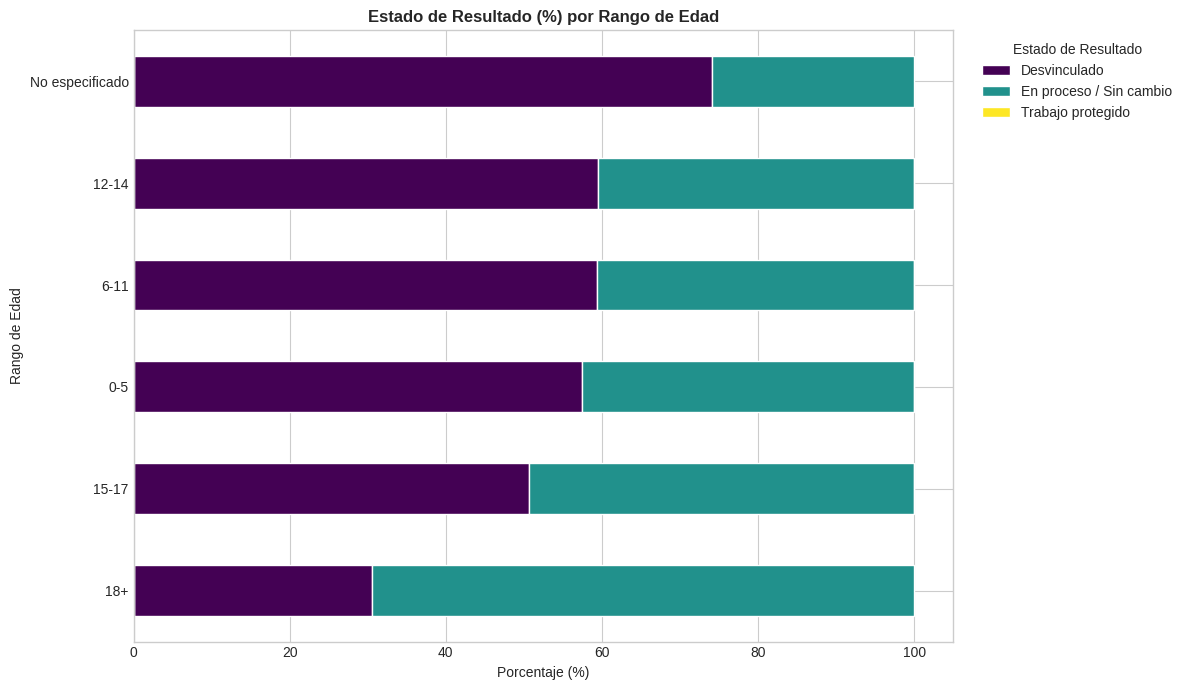

In [14]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS Y VISUALIZACIÓN: ESTADO_RESULTADO vs RANGO_EDAD
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Analizando y visualizando: ESTADO_RESULTADO vs RANGO_EDAD")
print("="*70 + "\n")

if 'ESTADO_RESULTADO' in df.columns and 'RANGO_EDAD' in df.columns:
    # Asegurarse de que 'No especificado' en RANGO_EDAD se maneje
    df_viz_edad = df.copy()
    df_viz_edad['RANGO_EDAD_FILLED'] = df_viz_edad['RANGO_EDAD'].fillna("No especificado")

    # Calcular la tabla de contingencia y normalizar por filas (por rango de edad)
    cross_tab_edad = pd.crosstab(
        df_viz_edad['RANGO_EDAD_FILLED'],
        df_viz_edad['ESTADO_RESULTADO'],
        normalize='index'
    ) * 100

    # Ordenar por el porcentaje de "Desvinculado" para mejor visualización
    if 'Desvinculado' in cross_tab_edad.columns:
        cross_tab_edad = cross_tab_edad.sort_values('Desvinculado', ascending=True)
    else:
         # Si no hay 'Desvinculado', ordenar por otra columna relevante o dejar como está
         cross_tab_edad = cross_tab_edad.sort_index()


    fig, ax = plt.subplots(figsize=(12, 7))

    # Graficar la tabla de contingencia apilada
    cross_tab_edad.plot(kind='barh', stacked=True, ax=ax, colormap='viridis')

    ax.set_title('Estado de Resultado (%) por Rango de Edad', fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Rango de Edad')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')

    # Añadir etiquetas de porcentaje (opcional, puede saturar si hay muchas barras/categorias)
    # for container in ax.containers:
    #     ax.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=8)

    plt.tight_layout()
    os.makedirs('reports/visualizaciones_cruce', exist_ok=True)
    plt.savefig('reports/visualizaciones_cruce/estado_resultado_por_rango_edad.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_rango_edad.png")
    plt.show()

else:
    print("ℹ️ No se pudo generar el gráfico de ESTADO_RESULTADO vs RANGO_EDAD (faltan columnas).")


📊 Analizando y visualizando: % Desvinculado vs LOCALIDAD (Top N)

✓ Visualización guardada: reports/visualizaciones_cruce/pct_desvinculado_por_localidad.png


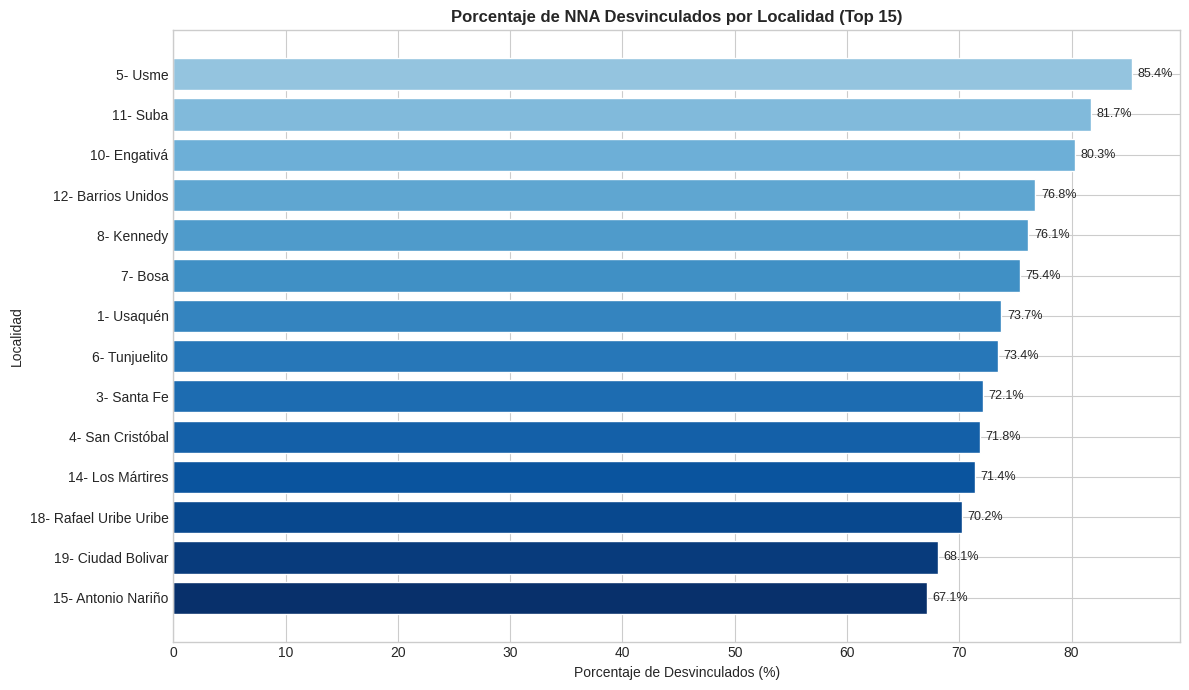

In [15]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS Y VISUALIZACIÓN: % Desvinculado vs LOCALIDAD (Top N)
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Analizando y visualizando: % Desvinculado vs LOCALIDAD (Top N)")
print("="*70 + "\n")

VAR_LOC = 'LOCALIDAD'
VAR_ESTADO = 'ESTADO_RESULTADO'
N_TOP_LOCALIDADES = 15 # Definir cuántas localidades mostrar

if VAR_ESTADO in df.columns and VAR_LOC in df.columns:

    # 1. Filtrar solo los casos "Desvinculado"
    df_desvinculado = df[df[VAR_ESTADO] == 'Desvinculado'].copy()

    # 2. Contar el total de casos por localidad
    total_por_localidad = df[VAR_LOC].value_counts().rename("Total").sort_index()

    # 3. Contar los casos desvinculados por localidad
    desvinculados_por_localidad = df_desvinculado[VAR_LOC].value_counts().rename("Desvinculado").sort_index()

    # 4. Combinar y calcular el porcentaje de desvinculados sobre el total
    df_resumen_localidad = pd.concat([total_por_localidad, desvinculados_por_localidad], axis=1).fillna(0)
    df_resumen_localidad['Pct_Desvinculado'] = (df_resumen_localidad['Desvinculado'] / df_resumen_localidad['Total']) * 100

    # 5. Filtrar por las N localidades con más registros totales y ordenar por % desvinculado
    top_localidades_nombres = df[VAR_LOC].value_counts().head(N_TOP_LOCALIDADES).index
    df_resumen_localidad_top = df_resumen_localidad.loc[top_localidades_nombres].sort_values('Pct_Desvinculado', ascending=False)

    # Eliminar la categoría '99999' si existe en las top N localidades
    if '99999' in df_resumen_localidad_top.index:
        df_resumen_localidad_top = df_resumen_localidad_top.drop('99999')

    if not df_resumen_localidad_top.empty:
        # 6. Visualizar
        fig, ax = plt.subplots(figsize=(12, 7))

        bars = ax.barh(
            df_resumen_localidad_top.index,
            df_resumen_localidad_top['Pct_Desvinculado'],
            color=plt.cm.Blues(np.linspace(0.4, 1, len(df_resumen_localidad_top))) # Gradiente de color
        )

        ax.set_title(f'Porcentaje de NNA Desvinculados por Localidad (Top {N_TOP_LOCALIDADES})', fontweight='bold')
        ax.set_xlabel('Porcentaje de Desvinculados (%)')
        ax.set_ylabel('Localidad')
        ax.invert_yaxis() # Localidad con mayor % arriba

        # Añadir etiquetas de porcentaje en las barras
        for bar in bars:
            width = bar.get_width()
            label_text = f'{width:.1f}%'
            x_pos = width + 0.5 # Posición al lado de la barra
            y_pos = bar.get_y() + bar.get_height()/2
            ax.text(x_pos, y_pos, label_text, va='center', ha='left', fontsize=9)


        plt.tight_layout()
        os.makedirs('reports/visualizaciones_cruce', exist_ok=True)
        plt.savefig('reports/visualizaciones_cruce/pct_desvinculado_por_localidad.png', dpi=300, bbox_inches='tight')
        print("✓ Visualización guardada: reports/visualizaciones_cruce/pct_desvinculado_por_localidad.png")
        plt.show()
    else:
         print(f"ℹ️ No hay suficientes datos en las top {N_TOP_LOCALIDADES} localidades para graficar el porcentaje de desvinculados (excluyendo '99999').")


else:
    print("ℹ️ No se pudo generar el gráfico de % Desvinculado vs LOCALIDAD (faltan columnas).")


📊 Analizando y visualizando: ESTADO_RESULTADO vs SEXO_LABEL

✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_sexo.png


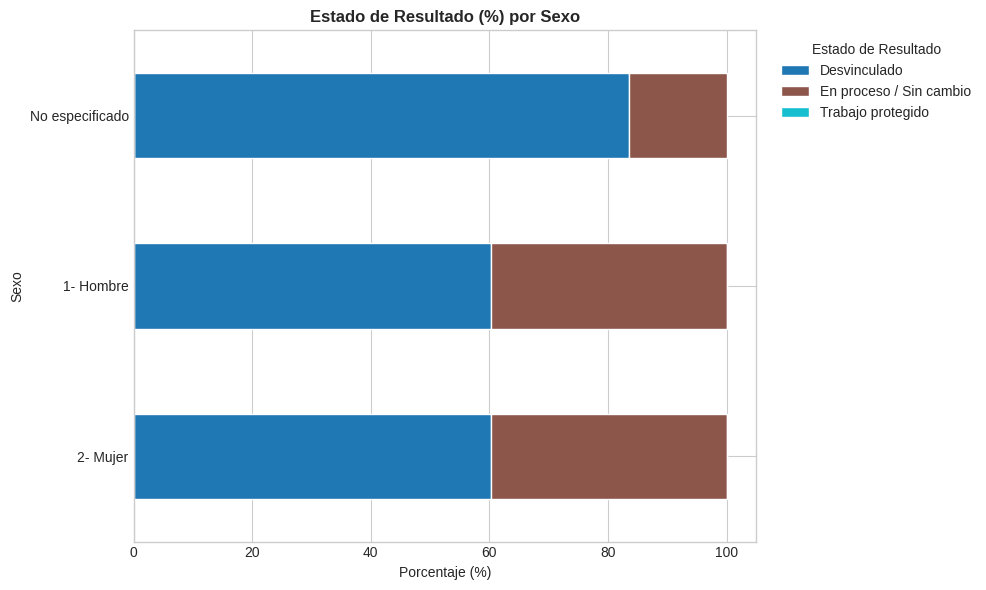

In [16]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS Y VISUALIZACIÓN: ESTADO_RESULTADO vs SEXO_LABEL
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Analizando y visualizando: ESTADO_RESULTADO vs SEXO_LABEL")
print("="*70 + "\n")

VAR_SEXO = 'SEXO_LABEL'
VAR_ESTADO = 'ESTADO_RESULTADO'

if VAR_ESTADO in df.columns and VAR_SEXO in df.columns:

    # Calcular la tabla de contingencia y normalizar por filas (por sexo)
    cross_tab_sexo = pd.crosstab(
        df[VAR_SEXO],
        df[VAR_ESTADO],
        normalize='index'
    ) * 100

    # Ordenar para mejor visualización (ej. por % Desvinculado)
    if 'Desvinculado' in cross_tab_sexo.columns:
         cross_tab_sexo = cross_tab_sexo.sort_values('Desvinculado', ascending=True)
    else:
        cross_tab_sexo = cross_tab_sexo.sort_index()


    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar la tabla de contingencia apilada
    cross_tab_sexo.plot(kind='barh', stacked=True, ax=ax, colormap='tab10')

    ax.set_title('Estado de Resultado (%) por Sexo', fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Sexo')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    os.makedirs('reports/visualizaciones_cruce', exist_ok=True)
    plt.savefig('reports/visualizaciones_cruce/estado_resultado_por_sexo.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_sexo.png")
    plt.show()

else:
    print("ℹ️ No se pudo generar el gráfico de ESTADO_RESULTADO vs SEXO_LABEL (faltan columnas).")


📊 Analizando y visualizando: ESTADO_RESULTADO vs ESTRATO_SOCIOECONÓMICO_LABEL

✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_estrato.png


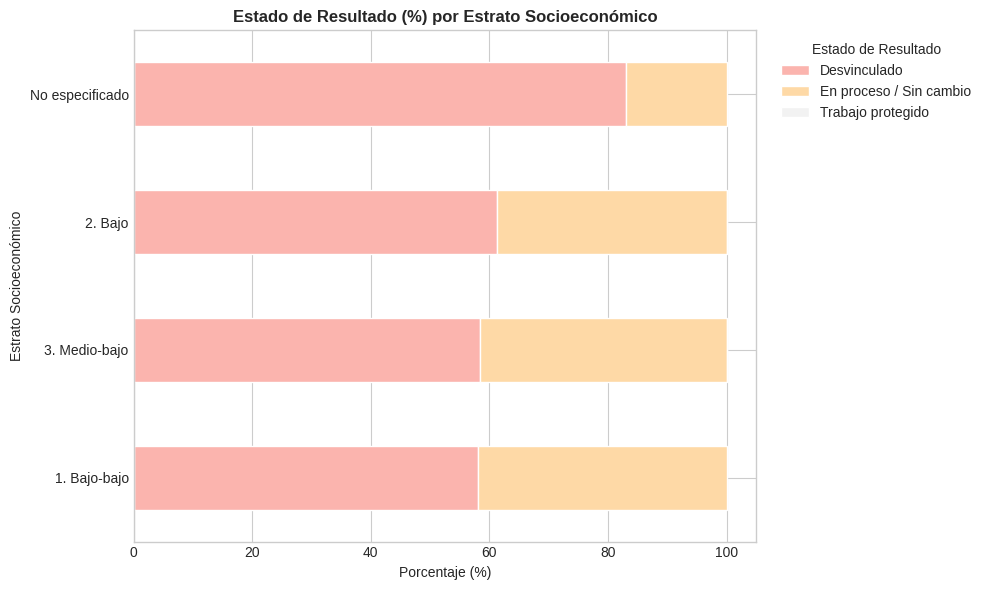

In [17]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS Y VISUALIZACIÓN: ESTADO_RESULTADO vs ESTRATO_SOCIOECONÓMICO_LABEL
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Analizando y visualizando: ESTADO_RESULTADO vs ESTRATO_SOCIOECONÓMICO_LABEL")
print("="*70 + "\n")

VAR_ESTRATO = 'ESTRATO_SOCIOECONÓMICO_LABEL'
VAR_ESTADO = 'ESTADO_RESULTADO'

if VAR_ESTADO in df.columns and VAR_ESTRATO in df.columns:

    # Calcular la tabla de contingencia y normalizar por filas (por estrato)
    cross_tab_estrato = pd.crosstab(
        df[VAR_ESTRATO],
        df[VAR_ESTADO],
        normalize='index'
    ) * 100

    # Ordenar para mejor visualización (ej. por % Desvinculado)
    if 'Desvinculado' in cross_tab_estrato.columns:
         cross_tab_estrato = cross_tab_estrato.sort_values('Desvinculado', ascending=True)
    else:
        cross_tab_estrato = cross_tab_estrato.sort_index()


    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar la tabla de contingencia apilada
    cross_tab_estrato.plot(kind='barh', stacked=True, ax=ax, colormap='Pastel1')

    ax.set_title('Estado de Resultado (%) por Estrato Socioeconómico', fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Estrato Socioeconómico')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    os.makedirs('reports/visualizaciones_cruce', exist_ok=True)
    plt.savefig('reports/visualizaciones_cruce/estado_resultado_por_estrato.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_estrato.png")
    plt.show()

else:
    print("ℹ️ No se pudo generar el gráfico de ESTADO_RESULTADO vs ESTRATO_SOCIOECONÓMICO_LABEL (faltan columnas).")


📊 Analizando y visualizando: ESTADO_RESULTADO vs AFILIACIÓN_AL_SGSSS_LABEL

✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_afiliacion.png


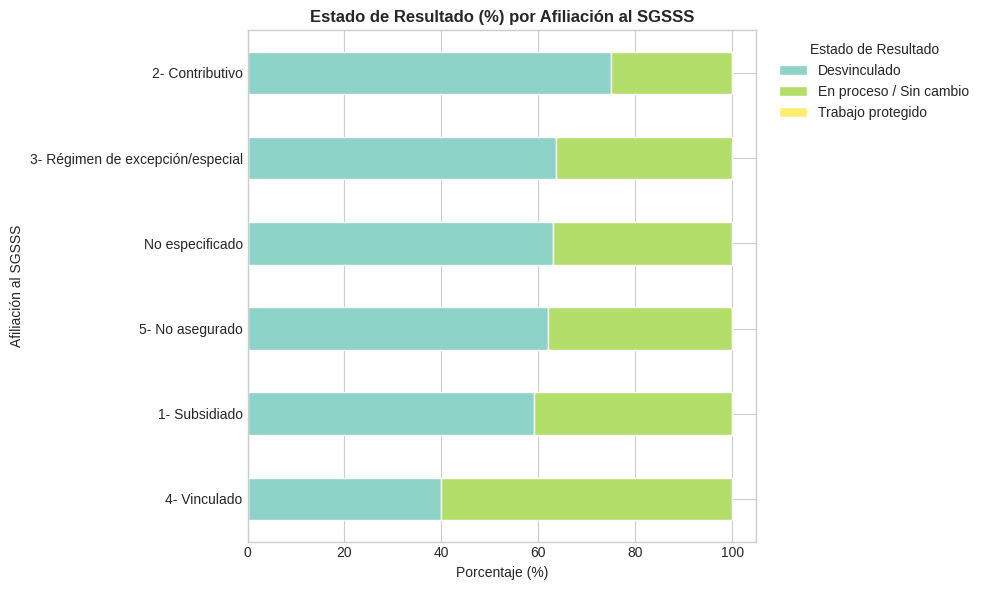

In [18]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS Y VISUALIZACIÓN: ESTADO_RESULTADO vs AFILIACIÓN_AL_SGSSS_LABEL
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Analizando y visualizando: ESTADO_RESULTADO vs AFILIACIÓN_AL_SGSSS_LABEL")
print("="*70 + "\n")

VAR_AFIL = 'AFILIACIÓN_AL_SGSSS_LABEL'
VAR_ESTADO = 'ESTADO_RESULTADO'

if VAR_ESTADO in df.columns and VAR_AFIL in df.columns:

    # Calcular la tabla de contingencia y normalizar por filas (por afiliación)
    cross_tab_afil = pd.crosstab(
        df[VAR_AFIL],
        df[VAR_ESTADO],
        normalize='index'
    ) * 100

    # Ordenar para mejor visualización (ej. por % Desvinculado)
    if 'Desvinculado' in cross_tab_afil.columns:
         cross_tab_afil = cross_tab_afil.sort_values('Desvinculado', ascending=True)
    else:
        cross_tab_afil = cross_tab_afil.sort_index()


    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar la tabla de contingencia apilada
    cross_tab_afil.plot(kind='barh', stacked=True, ax=ax, colormap='Set3')

    ax.set_title('Estado de Resultado (%) por Afiliación al SGSSS', fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Afiliación al SGSSS')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    os.makedirs('reports/visualizaciones_cruce', exist_ok=True)
    plt.savefig('reports/visualizaciones_cruce/estado_resultado_por_afiliacion.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_afiliacion.png")
    plt.show()

else:
    print("ℹ️ No se pudo generar el gráfico de ESTADO_RESULTADO vs AFILIACIÓN_AL_SGSSS_LABEL (faltan columnas).")


📊 Analizando y visualizando: ESTADO_RESULTADO vs LUGAR_TRABAJO_LABEL

✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_lugar_trabajo.png


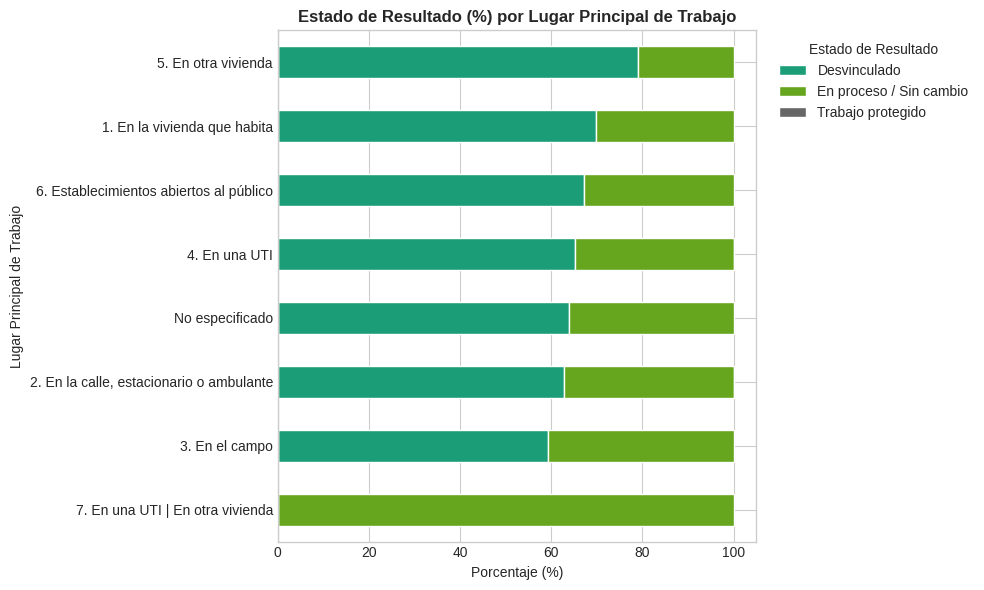

In [19]:
# ═══════════════════════════════════════════════════════════════
# ANÁLISIS Y VISUALIZACIÓN: ESTADO_RESULTADO vs LUGAR_TRABAJO_LABEL
# ═══════════════════════════════════════════════════════════════

print("\n" + "="*70)
print("📊 Analizando y visualizando: ESTADO_RESULTADO vs LUGAR_TRABAJO_LABEL")
print("="*70 + "\n")

VAR_LUGAR = 'LUGAR_TRABAJO_LABEL'
VAR_ESTADO = 'ESTADO_RESULTADO'

if VAR_ESTADO in df.columns and VAR_LUGAR in df.columns:

    # Calcular la tabla de contingencia y normalizar por filas (por lugar de trabajo)
    cross_tab_lugar = pd.crosstab(
        df[VAR_LUGAR],
        df[VAR_ESTADO],
        normalize='index'
    ) * 100

    # Ordenar para mejor visualización (ej. por % Desvinculado)
    if 'Desvinculado' in cross_tab_lugar.columns:
         cross_tab_lugar = cross_tab_lugar.sort_values('Desvinculado', ascending=True)
    else:
        cross_tab_lugar = cross_tab_lugar.sort_index()


    fig, ax = plt.subplots(figsize=(10, 6))

    # Graficar la tabla de contingencia apilada
    cross_tab_lugar.plot(kind='barh', stacked=True, ax=ax, colormap='Dark2')

    ax.set_title('Estado de Resultado (%) por Lugar Principal de Trabajo', fontweight='bold')
    ax.set_xlabel('Porcentaje (%)')
    ax.set_ylabel('Lugar Principal de Trabajo')
    ax.legend(title='Estado de Resultado', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    os.makedirs('reports/visualizaciones_cruce', exist_ok=True)
    plt.savefig('reports/visualizaciones_cruce/estado_resultado_por_lugar_trabajo.png', dpi=300, bbox_inches='tight')
    print("✓ Visualización guardada: reports/visualizaciones_cruce/estado_resultado_por_lugar_trabajo.png")
    plt.show()

else:
    print("ℹ️ No se pudo generar el gráfico de ESTADO_RESULTADO vs LUGAR_TRABAJO_LABEL (faltan columnas).")

Basándonos en los resultados de las visualizaciones generadas, podemos extraer algunas conclusiones preliminares sobre el 'ESTADO_RESULTADO' en relación con las variables analizadas:

*   **RANGO_EDAD:** Observamos diferencias notables en el porcentaje de desvinculación según el rango de edad. Los rangos de edad más jóvenes (0-5 y 6-11) parecen tener un porcentaje de desvinculación ligeramente menor en comparación con los adolescentes (12-14 y 15-17). La categoría 'No especificado' en edad presenta un porcentaje de desvinculación significativamente mayor, lo que podría indicar un sesgo en los datos o la necesidad de investigar más a fondo estos casos.
*   **LOCALIDAD:** El porcentaje de NNA desvinculados varía considerablemente entre localidades. Algunas localidades como Usme, Suba, y Engativá muestran porcentajes de desvinculación más altos entre las top 15 localidades con más registros, mientras que otras como Ciudad Bolívar y Antonio Nariño tienen porcentajes más bajos. Esto sugiere que la ubicación geográfica es un factor importante y que las estrategias de intervención podrían necesitar ajustarse a las particularidades de cada localidad. La categoría '99999' en Localidad presenta un porcentaje de desvinculación muy bajo, lo que refuerza la idea de que son datos atípicos o no corresponden a una localidad real.
*   **SEXO_LABEL:** Los porcentajes de desvinculación y "En proceso / Sin cambio" son bastante similares entre hombres y mujeres. La categoría 'No especificado' en sexo tiene un porcentaje de desvinculación notablemente más alto, similar a lo observado en el rango de edad 'No especificado'.
*   **ESTRATO_SOCIOECONÓMICO_LABEL:** El estrato 'No especificado' presenta el porcentaje más alto de desvinculación. Entre los estratos definidos, el estrato '2. Bajo' tiene un porcentaje de desvinculación ligeramente superior a los estratos '1. Bajo-bajo' y '3. Medio-bajo'.
*   **AFILIACIÓN_AL_SGSSS_LABEL:** Los NNA afiliados al régimen 'Contributivo' muestran un porcentaje de desvinculación más alto en comparación con otros regímenes de afiliación como el 'Subsidiado' o 'No asegurado'. Esto podría ser un hallazgo interesante para explorar las posibles razones detrás de esta diferencia. La categoría 'No especificado' también tiene un porcentaje de desvinculación relativamente alto.
*   **LUGAR_TRABAJO_LABEL:** El porcentaje de desvinculación varía según el lugar principal de trabajo. Lugares como "En una UTI" y "En la calle, estacionario o ambulante", que concentran un alto número de casos, tienen porcentajes de desvinculación por encima del promedio general. Los casos con "No especificado" en el lugar de trabajo también muestran un alto porcentaje de desvinculación.

En resumen, los análisis sugieren que tanto las variables demográficas (edad, sexo - especialmente en categorías no especificadas) como las geográficas (localidad) y socioeconómicas (estrato, afiliación a salud, lugar de trabajo) están relacionadas con el estado del resultado de la intervención. Las categorías "No especificado" en varias variables presentan un comportamiento atípico con porcentajes de desvinculación más altos, lo que justifica una revisión de la calidad o el significado de estos datos.

Estos hallazgos pueden ser el punto de partida para investigaciones más profundas y para orientar la toma de decisiones en la implementación de estrategias de intervención más focalizadas.

## Resumen de Hallazgos y Proceso (Hasta el Análisis Exploratorio)

Basándonos en los pasos de preparación de datos y análisis exploratorio realizados, podemos destacar los siguientes puntos:

1.  **Carga y Estructura de Datos:**
    *   Se cargó exitosamente el dataset inicial con **56,473 registros y 115 columnas**.
    *   Se estandarizaron los nombres de las columnas para facilitar el manejo (espacios por guion bajo, todo en mayúsculas).

2.  **Limpieza y Manejo de Faltantes:**
    *   Se identificaron y **eliminaron 10 columnas con información personal identificable (PII)** para asegurar la privacidad.
    *   Se realizó una limpieza general de texto en columnas categóricas (eliminación de espacios extra, manejo de strings vacíos).
    *   Se normalizaron valores específicos en columnas clave como SEXO y ZONA.
    *   Se identificaron y reemplazaron múltiples "tokens" de valores faltantes (como "NA", "SIN DATO", 99999) por valores estándar `NaN` en todo el dataset.
    *   Se realizó un resumen detallado de la cantidad y porcentaje de valores faltantes por variable, identificando variables con alto porcentaje de faltantes que podrían ser condicionales.
    *   Se imputaron valores faltantes en **8 variables categóricas no condicionales** con la etiqueta "No especificado".

3.  **Creación de Variables Derivadas:**
    *   Se crearon **9 variables nuevas** basadas en la lógica del negocio y la necesidad de análisis, manteniendo etiquetas claras y canónicas (ej. RANGO\_EDAD, ZONA\_LABEL, SEXO\_LABEL, ESTRATO\_SOCIOECONÓMICO\_LABEL, LUGAR\_TRABAJO\_LABEL, AFILIACIÓN\_AL\_SGSSS\_LABEL, FLAG\_AFILIACION\_SGSSS, ESTADO\_RESULTADO, UPZ\_UPR\_ALIAS). Estas variables facilitan el análisis y la visualización.

4.  **Estructuración Final:**
    *   Las columnas del dataset final (`df_final`) se reordenaron en grupos temáticos lógicos (Metadata, Ubicación, Demografía, Trabajo, Salud, Resultado) para una mejor organización.

5.  **Análisis y Visualización Exploratoria (Enfoque en ESTADO_RESULTADO):**
    *   Se generaron visualizaciones clave para entender la distribución de variables importantes (Rango de Edad, Sexo, Estrato, Afiliación, Lugar de Trabajo).
    *   Se realizaron cruces específicos para analizar el **'ESTADO\_RESULTADO'** en relación con otras variables:
        *   **RANGO\_EDAD:** Se observaron diferencias en el porcentaje de desvinculación entre rangos de edad, con adolescentes mostrando porcentajes ligeramente superiores y la categoría 'No especificado' destacando con un alto porcentaje de desvinculación.
        *   **LOCALIDAD:** El porcentaje de desvinculación varía significativamente entre localidades, sugiriendo la importancia del factor geográfico. Se identificaron localidades con mayores y menores tasas de desvinculación entre las que tienen más casos. La categoría '99999' en Localidad presentó un porcentaje de desvinculación muy bajo.
        *   **SEXO\_LABEL:** Los porcentajes de desvinculación fueron similares entre hombres y mujeres. La categoría 'No especificado' en sexo mostró un alto porcentaje de desvinculación.
        *   **ESTRATO\_SOCIOECONÓMICO\_LABEL:** El estrato 'No especificado' tuvo el mayor porcentaje de desvinculación. Entre los estratos definidos, el estrato '2. Bajo' mostró una tasa ligeramente superior.
        *   **AFILIACIÓN\_AL\_SGSSS\_LABEL:** Los afiliados al régimen 'Contributivo' presentaron un porcentaje de desvinculación más alto comparado con otros regímenes. La categoría 'No especificado' también tuvo un porcentaje relativamente alto.
        *   **LUGAR\_TRABAJO\_LABEL:** El porcentaje de desvinculación varió por lugar de trabajo, siendo mayor en "En una UTI", "En la calle, estacionario o ambulante" y "En la vivienda que habita". La categoría "No especificado" también mostró una alta tasa.

6.  **Calidad de Datos Final:**
    *   Se cuantificó la cantidad total de valores faltantes y filas duplicadas en el dataset final, documentado en el reporte JSON.

En general, el proceso de preparación permitió limpiar, transformar y estructurar los datos para un análisis más efectivo. El análisis exploratorio reveló patrones interesantes en la distribución de las variables clave y relaciones importantes entre las características demográficas, socioeconómicas, geográficas y el estado del resultado de la intervención, destacando la necesidad de manejar con precaución las categorías "No especificado" debido a su comportamiento atípico.

In [20]:
# ═══════════════════════════════════════════════════════════════
# APLICAR PRUEBA CHI-CUADRADO
# ═══════════════════════════════════════════════════════════════

from scipy.stats import chi2_contingency
import pandas as pd
import numpy as np

print("\n" + "="*70)
print("🧪 Aplicando Prueba Chi-cuadrado a variables clave vs ESTADO_RESULTADO")
print("="*70 + "\n")

VAR_ESTADO = 'ESTADO_RESULTADO'
variables_a_testear = [
    'RANGO_EDAD_FILLED', # Usamos la versión con "No especificado" imputado temporalmente
    'LOCALIDAD',
    'SEXO_LABEL',
    'ESTRATO_SOCIOECONÓMICO_LABEL',
    'AFILIACIÓN_AL_SGSSS_LABEL',
    'LUGAR_TRABAJO_LABEL'
]

# Asegurarse de que la columna RANGO_EDAD_FILLED existe si no se ejecutó la celda anterior
if 'RANGO_EDAD' in df.columns and 'RANGO_EDAD_FILLED' not in df.columns:
     df['RANGO_EDAD_FILLED'] = df['RANGO_EDAD'].fillna("No especificado")
     print("ℹ️ Columna 'RANGO_EDAD_FILLED' creada para el test.")


for var in variables_a_testear:
    if var in df.columns and VAR_ESTADO in df.columns:
        print(f"--- Prueba Chi-cuadrado para: {var} vs {VAR_ESTADO} ---")
        try:
            # Crear tabla de contingencia, manejando posibles NaNs si no se imputaron
            # Explícitamente manejar NaNs para que no se incluyan en el crosstab por defecto si existen
            df_temp = df[[var, VAR_ESTADO]].dropna()
            if df_temp.empty:
                print(f"  ⚠️ No hay datos válidos para '{var}' y '{VAR_ESTADO}'. Saltando test.")
                print("-" * (len(var) + len(VAR_ESTADO) + 27) + "\n")
                continue

            cross_tab = pd.crosstab(df_temp[var], df_temp[VAR_ESTADO])

            # Verificar si hay celdas con frecuencias esperadas bajas
            chi2, p, dof, expected = chi2_contingency(cross_tab)

            print(f"  Estadístico Chi-cuadrado: {chi2:.4f}")
            print(f"  P-valor: {p:.4f}")
            print(f"  Grados de libertad: {dof}")

            # Opcional: advertir sobre frecuencias esperadas bajas
            low_expected = (expected < 5).sum()
            total_cells = expected.size
            pct_low_expected = (low_expected / total_cells) * 100 if total_cells > 0 else 0

            if pct_low_expected > 20:
                 print(f"  ⚠️ Advertencia: {low_expected}/{total_cells} ({pct_low_expected:.1f}%) de las celdas tienen frecuencias esperadas < 5. Los resultados pueden no ser confiables.")
            elif low_expected > 0:
                 print(f"  ℹ️ {low_expected}/{total_cells} ({pct_low_expected:.1f}%) de las celdas tienen frecuencias esperadas < 5.")


        except ValueError as ve:
            print(f"  ❌ Error al aplicar Chi-cuadrado para '{var}': {ve}")
            print("     Esto puede ocurrir si alguna fila o columna de la tabla de contingencia es cero después de remover NaNs.")
        except Exception as e:
            print(f"  ❌ Ocurrió un error inesperado para '{var}': {e}")

        print("-" * (len(var) + len(VAR_ESTADO) + 27) + "\n")

    else:
        print(f"ℹ️ Columna '{var}' o '{VAR_ESTADO}' no encontrada en el DataFrame. Saltando test para '{var}'.")
        print("-" * (len(var) + 27) + "\n")


print("✅ Pruebas Chi-cuadrado completadas.")


🧪 Aplicando Prueba Chi-cuadrado a variables clave vs ESTADO_RESULTADO

ℹ️ Columna 'RANGO_EDAD_FILLED' creada para el test.
--- Prueba Chi-cuadrado para: RANGO_EDAD_FILLED vs ESTADO_RESULTADO ---
  Estadístico Chi-cuadrado: 1803.8513
  P-valor: 0.0000
  Grados de libertad: 10
  ⚠️ Advertencia: 6/18 (33.3%) de las celdas tienen frecuencias esperadas < 5. Los resultados pueden no ser confiables.
------------------------------------------------------------

--- Prueba Chi-cuadrado para: LOCALIDAD vs ESTADO_RESULTADO ---
  Estadístico Chi-cuadrado: 13001.8043
  P-valor: 0.0000
  Grados de libertad: 40
  ⚠️ Advertencia: 23/63 (36.5%) de las celdas tienen frecuencias esperadas < 5. Los resultados pueden no ser confiables.
----------------------------------------------------

--- Prueba Chi-cuadrado para: SEXO_LABEL vs ESTADO_RESULTADO ---
  Estadístico Chi-cuadrado: 2137.2930
  P-valor: 0.0000
  Grados de libertad: 4
  ⚠️ Advertencia: 3/9 (33.3%) de las celdas tienen frecuencias esperadas < 

## Conclusiones de las Pruebas de Asociación con el Estado de Resultado

Las pruebas de Chi-cuadrado aplicadas para evaluar la asociación entre diferentes variables categóricas y el 'ESTADO_RESULTADO' arrojaron los siguientes hallazgos:

**Variables con Asociación Estadísticamente Significativa (p-valor < 0.05):**

Para todas las variables analizadas (`RANGO_EDAD_FILLED`, `LOCALIDAD`, `SEXO_LABEL`, `ESTRATO_SOCIOECONÓMICO_LABEL`, `AFILIACIÓN_AL_SGSSS_LABEL`, y `LUGAR_TRABAJO_LABEL`), el p-valor obtenido fue 0.0000, que es significativamente menor que el nivel de significancia común de 0.05. Esto nos permite rechazar la hipótesis nula de independencia para cada par de variables.

**Interpretación:**

Existe una **asociación estadísticamente significativa** entre el 'ESTADO_RESULTADO' (Desvinculado, En proceso / Sin cambio, Trabajo protegido) y cada una de las siguientes variables:

*   **RANGO_EDAD_FILLED:** La distribución del 'ESTADO_RESULTADO' no es independiente del rango de edad del NNA. Como observamos en la visualización previa, los diferentes rangos de edad muestran distintas proporciones de desvinculación y de casos "En proceso". La categoría "No especificado" en edad también muestra un comportamiento particular.
*   **LOCALIDAD:** El estado del resultado de la intervención está asociado a la localidad donde se realizó la intervención. Las diferencias en los porcentajes de desvinculación entre localidades (como se vio en el gráfico del Top N) no se deben puramente al azar.
*   **SEXO_LABEL:** Aunque las visualizaciones iniciales mostraron proporciones similares entre hombres y mujeres para las categorías principales de resultado, la prueba Chi-cuadrado indica que, a nivel estadístico, hay una asociación. Es probable que esta asociación sea impulsada por las diferencias observadas en la categoría "No especificado" de sexo.
*   **ESTRATO_SOCIOECONÓMICO_LABEL:** Existe una relación entre el estrato socioeconómico reportado y el 'ESTADO_RESULTADO'. La categoría "No especificado" en estrato muestra una diferencia notable en los resultados.
*   **AFILIACIÓN_AL_SGSSS_LABEL:** El tipo de afiliación al sistema de salud está asociado con el resultado de la intervención. Las proporciones de los estados de resultado varían entre los diferentes tipos de afiliación.
*   **LUGAR_TRABAJO_LABEL:** El lugar principal donde el NNA realiza su trabajo está asociado con el 'ESTADO_RESULTADO'. Los diferentes lugares de trabajo presentan distintas tasas de desvinculación y otros resultados.

**Advertencias sobre Frecuencias Esperadas Bajas:**

Es importante notar que para varias de las pruebas, se emitió una advertencia debido a que un porcentaje significativo de celdas en las tablas de contingencia tenían frecuencias esperadas menores a 5. Esto sugiere que, si bien la prueba Chi-cuadrado detecta una asociación general, los resultados deben interpretarse con precaución, especialmente para categorías con muy baja frecuencia de casos. Para un análisis más riguroso en presencia de celdas con bajas frecuencias, se podría considerar la prueba exacta de Fisher o la agrupación de categorías si es conceptualmente adecuado.

**En resumen:**

Las pruebas estadísticas confirman que el 'ESTADO_RESULTADO' de la intervención no es independiente de las características demográficas (Edad, Sexo), socioeconómicas (Estrato, Afiliación al SGSSS), geográficas (Localidad) y laborales (Lugar de trabajo) del NNA. Estas variables son factores importantes a considerar al analizar y planificar intervenciones. Las categorías "No especificado" en varias variables muestran patrones atípicos que requieren una investigación adicional.